<a href="https://colab.research.google.com/github/juborduchi/governanca-digital_mre/blob/main/notebooks/analise_nota_mre.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importação de bibliotecas

In [1]:
import os
import json
import pandas as pd
import glob

!pip install wordcloud -q


# Acesso ao drive

In [2]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


# Organização dos JSONs no DataFrame

In [3]:
def consolidar_jsons_aninhados(caminho_diretorio):
    lista_dataframes = []

    # Listar arquivos
    arquivos = [f for f in os.listdir(caminho_diretorio) if f.endswith('.json')]

    if not arquivos:
        print("Nenhum arquivo JSON encontrado.")
        return None

    for arquivo in arquivos:
        caminho_completo = os.path.join(caminho_diretorio, arquivo)

        try:
            with open(caminho_completo, 'r', encoding='utf-8') as f:
                dados = json.load(f)

                # EXPLICAÇÃO TÉCNICA:
                # Se o seu JSON tem o formato {'_default': {'0': {...}, '1': {...}}},
                # precisamos extrair os valores da chave '_default'.
                if '_default' in dados:
                    # Transformamos os valores de '_default' em uma lista e normalizamos
                    conteudo = list(dados['_default'].values())
                    df_temp = pd.json_normalize(conteudo)
                else:
                    # Caso o JSON seja uma lista direta ou outra estrutura
                    df_temp = pd.json_normalize(dados)

                lista_dataframes.append(df_temp)
        except Exception as e:
            print(f"Erro ao processar {arquivo}: {e}")

    # Concatenar todos os arquivos processados
    df_final = pd.concat(lista_dataframes, ignore_index=True)

    # Limpeza de listas: Se os dados vierem como ['Brasil'], removemos os parênteses
    # Aplicamos uma função que extrai o primeiro elemento se o dado for uma lista
    df_final = df_final.applymap(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else x)

    return df_final

# --- CONFIGURAÇÃO DO CAMINHO ---
caminho_pasta = '/content/gdrive/MyDrive/Colab_Notebooks/pibic-2025-2026/json-notas/'

# Execução
df = consolidar_jsons_aninhados(caminho_pasta)

# Exibição do resultado
if df is not None:
    print("DataFrame Organizado:")
    display(df.head())

DataFrame Organizado:


/tmp/ipykernel_9874/1430405251.py:38: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_final = df_final.applymap(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else x)


,tipo_dado,pais,origem,sigla,classificado,categoria,autoria,titulo,subtitulo,data,...,nome_arquivo,dir_arquivo,dir_base,codigo_bd,dir_bd,nome_arq_bd,env_dir_bd,extra_01,extra_02,extra_03
0,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],Ministério das Relações Exteriores,Incidente em Seul,,29/10/2022,...,2022-10-29-22h44-BD_DE_LATAM_BRA_GOVFEDERAL_MR...,/hdvm12/bd/003/001/001/001/002/001/dados/2022/...,NA,bd/003/001/001/001/002/001,NA,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA-...,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,174,NA,NA
1,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],Ministério das Relações Exteriores,Nota Conjunta do Ministério das Relações Exter...,,27/10/2022,...,2022-10-27-11h00-BD_DE_LATAM_BRA_GOVFEDERAL_MR...,/hdvm12/bd/003/001/001/001/002/001/dados/2022/...,NA,bd/003/001/001/001/002/001,NA,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA-...,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,173,NA,NA
2,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],Ministério das Relações Exteriores,Nota conjunta do Ministério das Relações Exter...,,25/10/2022,...,2022-10-25-17h14-BD_DE_LATAM_BRA_GOVFEDERAL_MR...,/hdvm12/bd/003/001/001/001/002/001/dados/2022/...,NA,bd/003/001/001/001/002/001,NA,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA-...,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,172,NA,NA
3,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],Ministério das Relações Exteriores,Comunicado Conjunto entre os Ministros das Rel...,,24/10/2022,...,2022-10-24-21h13-BD_DE_LATAM_BRA_GOVFEDERAL_MR...,/hdvm12/bd/003/001/001/001/002/001/dados/2022/...,NA,bd/003/001/001/001/002/001,NA,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA-...,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,171,NA,NA
4,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],Ministério das Relações Exteriores,Nota conjunta do Ministério das Relações Exter...,,24/10/2022,...,2022-10-24-11h16-BD_DE_LATAM_BRA_GOVFEDERAL_MR...,/hdvm12/bd/003/001/001/001/002/001/dados/2022/...,NA,bd/003/001/001/001/002/001,NA,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA-...,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,170,NA,NA


In [4]:
df.columns

Index(['tipo_dado', 'pais', 'origem', 'sigla', 'classificado', 'categoria',
       'autoria', 'titulo', 'subtitulo', 'data', 'horario', 'datatime',
       'data_atualizado', 'horario_atualizado', 'link', 'link_archive',
       'data_archive', 'horario_archive', 'local', 'tags', 'paragrafos',
       'imagens', 'nome_arquivo', 'dir_arquivo', 'dir_base', 'codigo_bd',
       'dir_bd', 'nome_arq_bd', 'env_dir_bd', 'extra_01', 'extra_02',
       'extra_03'],
      dtype='object')

# Preparação dos dados para análise

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1.1 — Converter data para datetime (dayfirst pq é formato brasileiro: dd/mm/aaaa)
df['data_dt'] = pd.to_datetime(df['data'], dayfirst=True, errors='coerce')

# 1.2 — Juntar os parágrafos (que são listas) em um único texto
df['texto'] = df['paragrafos'].apply(lambda lista: ' '.join(lista) if isinstance(lista, list) else str(lista))

# 1.3 — Coluna com tudo junto e em minúsculas (facilita buscas)
df['texto_completo'] = (df['titulo'].fillna('') + ' ' + df['texto']).str.lower()

# 1.4 — Extrair a hora como número inteiro (de "19h20" tira o 19)
df['hora_int'] = df['horario'].str.extract(r'(\d{1,2})').astype(float)

# 1.5 — Colunas auxiliares de tempo
df['ano_mes'] = df['data_dt'].dt.to_period('M')
df['dia_semana'] = df['data_dt'].dt.day_name()
df['tamanho_texto'] = df['texto'].str.len()
df['qtd_paragrafos'] = df['paragrafos'].apply(lambda x: len(x) if isinstance(x, list) else 0)

print(f"Total de notas: {len(df)}")
print(f"Período: de {df['data_dt'].min().date()} até {df['data_dt'].max().date()}")
df[['titulo', 'data_dt', 'hora_int', 'qtd_paragrafos', 'tamanho_texto']].head()

Total de notas: 5169
Período: de 2014-01-02 até 2025-12-31


,titulo,data_dt,hora_int,qtd_paragrafos,tamanho_texto
0,Incidente em Seul,2022-10-29,22.0,0,177
1,Nota Conjunta do Ministério das Relações Exter...,2022-10-27,11.0,0,717
2,Nota conjunta do Ministério das Relações Exter...,2022-10-25,17.0,0,129
3,Comunicado Conjunto entre os Ministros das Rel...,2022-10-24,21.0,0,434
4,Nota conjunta do Ministério das Relações Exter...,2022-10-24,11.0,0,460


In [6]:
df_customizado = df[["autoria","titulo",
       "data_atualizado", "horario_atualizado", "link", "paragrafos", "texto_completo","data_dt", "hora_int", "qtd_paragrafos", "tamanho_texto"]]
df_customizado

,autoria,titulo,data_atualizado,horario_atualizado,link,paragrafos,texto_completo,data_dt,hora_int,qtd_paragrafos,tamanho_texto
0,Ministério das Relações Exteriores,Incidente em Seul,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,O Governo brasileiro tomou conhecimento com gr...,incidente em seul o governo brasileiro tomou c...,2022-10-29,22.0,0,177
1,Ministério das Relações Exteriores,Nota Conjunta do Ministério das Relações Exter...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,A Comissão de Comércio Internacional dos Est...,nota conjunta do ministério das relações exter...,2022-10-27,11.0,0,717
2,Ministério das Relações Exteriores,Nota conjunta do Ministério das Relações Exter...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,"Em 19 de outubro, o Brasil depositou junto às...",nota conjunta do ministério das relações exter...,2022-10-25,17.0,0,129
3,Ministério das Relações Exteriores,Comunicado Conjunto entre os Ministros das Rel...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,Por ocasião da Visita Oficial do Ministro de ...,comunicado conjunto entre os ministros das rel...,2022-10-24,21.0,0,434
4,Ministério das Relações Exteriores,Nota conjunta do Ministério das Relações Exter...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,"Entre os dias 26 de setembro e 14 de outubro, ...",nota conjunta do ministério das relações exter...,2022-10-24,11.0,0,460
...,...,...,...,...,...,...,...,...,...,...,...
5164,NA,Cúpula de Chefes de Estado do MERCOSUL e Estad...,31/10/2022,17h45,https://www.gov.br/mre/pt-br/canais_atendiment...,"A Presidenta Dilma Rousseff participará, em Ca...",cúpula de chefes de estado do mercosul e estad...,2014-08-07,20.0,0,286
5165,NA,XLVI Reunião do Conselho do Mercado Comum e Cú...,31/10/2022,17h45,https://www.gov.br/mre/pt-br/canais_atendiment...,Informa-se o número do telefone celular do coo...,xlvi reunião do conselho do mercado comum e cú...,2014-08-07,20.0,0,213
5166,NA,Calendário de eventos entre 26 de julho e 03 d...,31/10/2022,17h45,https://www.gov.br/mre/pt-br/canais_atendiment...,"28 e 29/JUL – Rio de Janeiro, RJ. III Encontro...",calendário de eventos entre 26 de julho e 03 d...,2014-08-07,20.0,0,88
5167,NA,Cerimônia de posse do Presidente da República ...,31/10/2022,17h45,https://www.gov.br/mre/pt-br/canais_atendiment...,Os profissionais de imprensa interessados em p...,cerimônia de posse do presidente da república ...,2014-08-07,20.0,0,321


In [7]:
df.shape

(5169, 40)

In [8]:
df_customizado.describe(include="all")

,autoria,titulo,data_atualizado,horario_atualizado,link,paragrafos,texto_completo,data_dt,hora_int,qtd_paragrafos,tamanho_texto
count,5169,5169,5169,5169,5169,5169,5169,5169,5169.000000,5169.0,5169.000000
unique,2,4922,659,669,5169,4975,5156,NaN,NaN,NaN,NaN
top,Ministério das Relações Exteriores,Situação em Israel e na Palestina. Repatriação...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,.,comunicado do grupo de lima tradução não oficial,NaN,NaN,NaN,NaN
freq,2873,14,2942,2942,1,26,3,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-02-29 02:14:33.360418048,16.212033,0.0,327.447088
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-01-02 00:00:00,0.000000,0.0,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-08-25 00:00:00,13.000000,0.0,172.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-06-26 00:00:00,17.000000,0.0,245.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-12-08 00:00:00,20.000000,0.0,359.000000
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-12-31 00:00:00,23.000000,0.0,57109.000000


In [9]:
notas_por_dia = df['data_dt'].value_counts().sort_index()

display(notas_por_dia)

,count
data_dt,
2014-01-02,1
2014-01-03,1
2014-01-08,1
2014-01-10,2
2014-01-14,3
...,...
2025-12-22,2
2025-12-24,1
2025-12-26,1


## Verificando duplicatas

In [10]:
# Duplicatas por link (cada nota deveria ter um link único)
print("Duplicatas por link:", df.duplicated(subset=['link']).sum())

# Duplicatas por título
print("Duplicatas por título:", df.duplicated(subset=['titulo']).sum())




Duplicatas por link: 0
Duplicatas por título: 247


In [11]:

print("\n--- Registros com Títulos Duplicados ---")
duplicadas_titulo = df[df.duplicated(subset=['titulo'], keep=False)]
print(f"Total de linhas envolvidas em duplicatas de título: {len(duplicadas_titulo)}")
display(duplicadas_titulo.sort_values(by='titulo'))


--- Registros com Títulos Duplicados ---
Total de linhas envolvidas em duplicatas de título: 366


,tipo_dado,pais,origem,sigla,classificado,categoria,autoria,titulo,subtitulo,data,...,extra_02,extra_03,data_dt,texto,texto_completo,hora_int,ano_mes,dia_semana,tamanho_texto,qtd_paragrafos
75,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,21ª Conferência das Partes da Convenção-Quadro...,,09/11/2015,...,NA,NA,2015-11-09,"Foi antecipado, para hoje, dia 9 de novembro, ...",21ª conferência das partes da convenção-quadro...,13.0,2015-11,Monday,362,0
408,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,21ª Conferência das Partes da Convenção-Quadro...,,27/10/2015,...,NA,NA,2015-10-27,Encerra-se no próximo dia 20 de novembro o pra...,21ª conferência das partes da convenção-quadro...,18.0,2015-10,Tuesday,326,0
3020,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],Ministério das Relações Exteriores,Abertura de mercado no Peru - Nota Conjunta MR...,,08/04/2025,...,NA,NA,2025-04-08,O governo brasileiro e o governo peruano concl...,abertura de mercado no peru - nota conjunta mr...,13.0,2025-04,Tuesday,189,0
3010,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],Ministério das Relações Exteriores,Abertura de mercado no Peru - Nota Conjunta MR...,,17/04/2025,...,NA,NA,2025-04-17,O governo brasileiro e o governo peruano concl...,abertura de mercado no peru - nota conjunta mr...,17.0,2025-04,Thursday,165,0
1458,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],Ministério das Relações Exteriores,Acidente aéreo na Indonésia,,29/10/2018,...,NA,NA,2018-10-29,O governo brasileiro manifesta seu profundo pe...,acidente aéreo na indonésia o governo brasilei...,22.0,2018-10,Monday,223,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4093,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,Visita da Comissão de Chanceleres da UNASUL à ...,,05/03/2015,...,NA,NA,2015-03-05,"O Ministro das Relações Exteriores, Embaixador...",visita da comissão de chanceleres da unasul à ...,18.0,2015-03,Thursday,344,0
1414,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],Ministério das Relações Exteriores,Visita do Ministro Mauro Vieira a Omã – 8 de s...,,08/09/2024,...,NA,NA,2024-09-08,"O Ministro das Relações Exteriores, Mauro Vi...",visita do ministro mauro vieira a omã – 8 de s...,8.0,2024-09,Sunday,519,0
1415,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],Ministério das Relações Exteriores,Visita do Ministro Mauro Vieira a Omã – 8 de s...,,07/09/2024,...,NA,NA,2024-09-07,"O Ministro das Relações Exteriores, Mauro Vi...",visita do ministro mauro vieira a omã – 8 de s...,15.0,2024-09,Saturday,519,0
5103,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,Visita do ministro Aloysio Nunes Ferreira ao C...,,19/04/2017,...,NA,NA,2017-04-19,"O ministro Aloysio Nunes Ferreira realiza, nos...",visita do ministro aloysio nunes ferreira ao c...,19.0,2017-04,Wednesday,107,0


### Verificando duplicata por titulo

In [12]:
# Supondo que seu DataFrame seja 'df'
coluna_busca = 'titulo' # ou 'link'

# 1. Contagem de "Excedentes" (O que o seu .sum() estava fazendo)
total_excedentes = df.duplicated(subset=[coluna_busca], keep='first').sum()

# 2. DataFrame de Visualização (Todas as ocorrências)
df_todas_duplicatas = df[df.duplicated(subset=[coluna_busca], keep=False)]
total_na_visualizacao = len(df_todas_duplicatas)

print(f"--- Relatório de Consistência: {coluna_busca} ---")
print(f"Quantidade de cópias excedentes (sum): {total_excedentes}")
print(f"Total de linhas que são duplicatas entre si: {total_na_visualizacao}")
print("-" * 40)

# 3. Exibição Estruturada
# Ordenamos para que você veja os grupos de duplicatas lado a lado
if not df_todas_duplicatas.empty:
    print(f"Listando as duplicatas de {coluna_busca}:")
    display(df_todas_duplicatas.sort_values(by=coluna_busca))
else:
    print("Nenhuma duplicata encontrada com os parâmetros atuais.")


--- Relatório de Consistência: titulo ---
Quantidade de cópias excedentes (sum): 247
Total de linhas que são duplicatas entre si: 366
----------------------------------------
Listando as duplicatas de titulo:


,tipo_dado,pais,origem,sigla,classificado,categoria,autoria,titulo,subtitulo,data,...,extra_02,extra_03,data_dt,texto,texto_completo,hora_int,ano_mes,dia_semana,tamanho_texto,qtd_paragrafos
75,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,21ª Conferência das Partes da Convenção-Quadro...,,09/11/2015,...,NA,NA,2015-11-09,"Foi antecipado, para hoje, dia 9 de novembro, ...",21ª conferência das partes da convenção-quadro...,13.0,2015-11,Monday,362,0
408,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,21ª Conferência das Partes da Convenção-Quadro...,,27/10/2015,...,NA,NA,2015-10-27,Encerra-se no próximo dia 20 de novembro o pra...,21ª conferência das partes da convenção-quadro...,18.0,2015-10,Tuesday,326,0
3020,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],Ministério das Relações Exteriores,Abertura de mercado no Peru - Nota Conjunta MR...,,08/04/2025,...,NA,NA,2025-04-08,O governo brasileiro e o governo peruano concl...,abertura de mercado no peru - nota conjunta mr...,13.0,2025-04,Tuesday,189,0
3010,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],Ministério das Relações Exteriores,Abertura de mercado no Peru - Nota Conjunta MR...,,17/04/2025,...,NA,NA,2025-04-17,O governo brasileiro e o governo peruano concl...,abertura de mercado no peru - nota conjunta mr...,17.0,2025-04,Thursday,165,0
1458,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],Ministério das Relações Exteriores,Acidente aéreo na Indonésia,,29/10/2018,...,NA,NA,2018-10-29,O governo brasileiro manifesta seu profundo pe...,acidente aéreo na indonésia o governo brasilei...,22.0,2018-10,Monday,223,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4093,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,Visita da Comissão de Chanceleres da UNASUL à ...,,05/03/2015,...,NA,NA,2015-03-05,"O Ministro das Relações Exteriores, Embaixador...",visita da comissão de chanceleres da unasul à ...,18.0,2015-03,Thursday,344,0
1414,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],Ministério das Relações Exteriores,Visita do Ministro Mauro Vieira a Omã – 8 de s...,,08/09/2024,...,NA,NA,2024-09-08,"O Ministro das Relações Exteriores, Mauro Vi...",visita do ministro mauro vieira a omã – 8 de s...,8.0,2024-09,Sunday,519,0
1415,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],Ministério das Relações Exteriores,Visita do Ministro Mauro Vieira a Omã – 8 de s...,,07/09/2024,...,NA,NA,2024-09-07,"O Ministro das Relações Exteriores, Mauro Vi...",visita do ministro mauro vieira a omã – 8 de s...,15.0,2024-09,Saturday,519,0
5103,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,Visita do ministro Aloysio Nunes Ferreira ao C...,,19/04/2017,...,NA,NA,2017-04-19,"O ministro Aloysio Nunes Ferreira realiza, nos...",visita do ministro aloysio nunes ferreira ao c...,19.0,2017-04,Wednesday,107,0


In [13]:
df_teste = df_todas_duplicatas[["titulo","link"]]
df_teste

,titulo,link
19,Nota conjunta do Ministério das Relações Exter...,https://www.gov.br/mre/pt-br/canais_atendiment...
20,Nota conjunta do Ministério das Relações Exter...,https://www.gov.br/mre/pt-br/canais_atendiment...
35,Eleições na Guiana,https://www.gov.br/mre/pt-br/canais_atendiment...
54,Atentado na Nigéria,https://www.gov.br/mre/pt-br/canais_atendiment...
75,21ª Conferência das Partes da Convenção-Quadro...,https://www.gov.br/mre/pt-br/canais_atendiment...
...,...,...
5116,Conflito na Síria,https://www.gov.br/mre/pt-br/canais_atendiment...
5122,Situação no Paraguai,https://www.gov.br/mre/pt-br/canais_atendiment...
5126,Comunicado sobre a Venezuela,https://www.gov.br/mre/pt-br/canais_atendiment...
5141,Atentado no Afeganistão,https://www.gov.br/mre/pt-br/canais_atendiment...


[Tabela duplicatas por titulo](https://docs.google.com/spreadsheets/d/1BfJQLx3d--ejWnkmRbHOJFZRgvkRLnr9/edit?gid=585304390#gid=585304390)

### Verificando duplicata por texto

In [14]:
# Supondo que seu DataFrame seja 'df'
coluna_busca = 'texto_completo' # ou 'link'

# 1. Contagem de "Excedentes" (O que o seu .sum() estava fazendo)
duplicatas_texto = df.duplicated(subset=[coluna_busca], keep='first').sum()

# 2. DataFrame de Visualização (Todas as ocorrências)
df_duplicatas_texto = df[df.duplicated(subset=[coluna_busca], keep=False)]
total_na_visualizacao = len(df_duplicatas_texto)

print(f"--- Relatório de Consistência: {coluna_busca} ---")
print(f"Quantidade de cópias excedentes (sum): {duplicatas_texto}")
print(f"Total de linhas que são duplicatas entre si: {total_na_visualizacao}")
print("-" * 40)

# 3. Exibição Estruturada
# Ordenamos para que você veja os grupos de duplicatas lado a lado
if not df_duplicatas_texto.empty:
    print(f"Listando as duplicatas de {coluna_busca}:")
    display(df_duplicatas_texto.sort_values(by=coluna_busca))
else:
    print("Nenhuma duplicata encontrada com os parâmetros atuais.")

--- Relatório de Consistência: texto_completo ---
Quantidade de cópias excedentes (sum): 13
Total de linhas que são duplicatas entre si: 24
----------------------------------------
Listando as duplicatas de texto_completo:


,tipo_dado,pais,origem,sigla,classificado,categoria,autoria,titulo,subtitulo,data,...,extra_02,extra_03,data_dt,texto,texto_completo,hora_int,ano_mes,dia_semana,tamanho_texto,qtd_paragrafos
3098,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,Comunicado do Grupo de Lima,,14/05/2018,...,NA,NA,2018-05-14,Tradução não oficial,comunicado do grupo de lima tradução não oficial,22.0,2018-05,Monday,20,0
3140,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,Comunicado do Grupo de Lima,,07/04/2018,...,NA,NA,2018-04-07,Tradução não oficial,comunicado do grupo de lima tradução não oficial,16.0,2018-04,Saturday,20,0
3088,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,Comunicado do Grupo de Lima,,18/05/2018,...,NA,NA,2018-05-18,Tradução não oficial,comunicado do grupo de lima tradução não oficial,22.0,2018-05,Friday,20,0
5104,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,Comunicado sobre a Venezuela,,17/04/2017,...,NA,NA,2017-04-17,Comunicado sobre a Venezuela,comunicado sobre a venezuela comunicado sobre ...,23.0,2017-04,Monday,28,0
5126,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,Comunicado sobre a Venezuela,,30/04/2017,...,NA,NA,2017-04-30,Comunicado sobre a Venezuela,comunicado sobre a venezuela comunicado sobre ...,23.0,2017-04,Sunday,28,0
2574,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,Concessão de agrément ao Embaixador do Brasil ...,,20/01/2016,...,NA,NA,2016-01-20,Concessão de agrément ao Embaixador do Brasil ...,concessão de agrément ao embaixador do brasil ...,14.0,2016-01,Wednesday,59,0
4113,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,Concessão de agrément ao Embaixador do Brasil ...,,20/03/2015,...,NA,NA,2015-03-20,Concessão de agrément ao Embaixador do Brasil ...,concessão de agrément ao embaixador do brasil ...,22.0,2015-03,Friday,59,0
5067,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,Declaração do Grupo de Lima,,14/02/2018,...,NA,NA,2018-02-14,Tradução não oficial,declaração do grupo de lima tradução não oficial,11.0,2018-02,Wednesday,20,0
300,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,Declaração do Grupo de Lima,,15/09/2018,...,NA,NA,2018-09-15,Tradução não oficial,declaração do grupo de lima tradução não oficial,22.0,2018-09,Saturday,20,0
4232,aberto,Brasil,ministerio das relações exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_NOTAS_IMPRENSA,noticias institucionais,[],NA,Declaração do Grupo de Lima,,13/08/2018,...,NA,NA,2018-08-13,Tradução não oficial,declaração do grupo de lima tradução não oficial,12.0,2018-08,Monday,20,0


# Análise e vizualiação de dados

## Volume de publicações

In [15]:
# Extrair apenas o ano
df["ano"] = df["data_dt"].dt.year

notas_por_ano = df['ano'].value_counts().sort_index()

display(notas_por_ano)

,count
ano,
2014,343
2015,536
2016,614
2017,499
2018,427
2019,318
2020,172
2021,186
2022,200


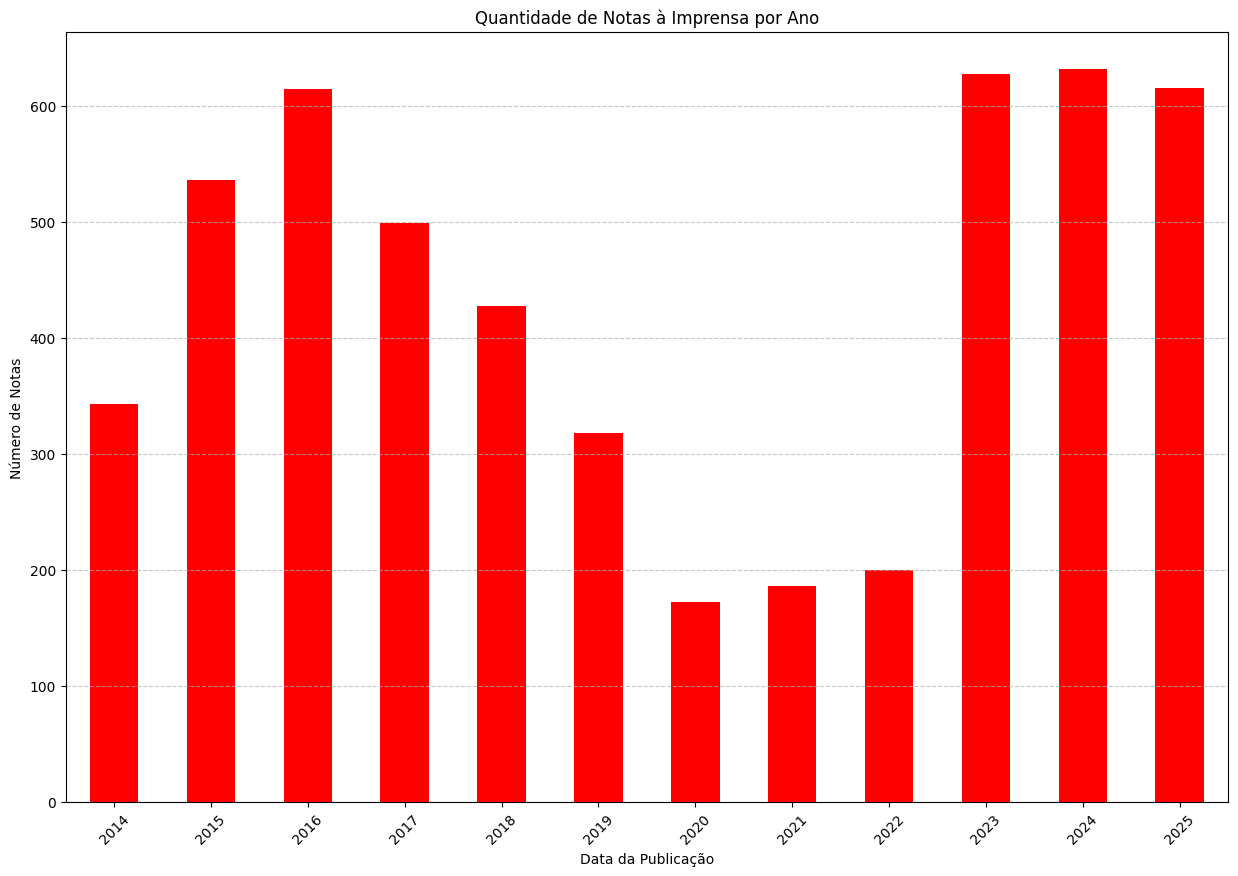

In [16]:
import matplotlib.pyplot as plt

# Criando o gráfico
plt.figure(figsize=(15, 10))
notas_por_ano.plot(kind='bar', color='red')

# Adicionando títulos e rótulos
plt.title('Quantidade de Notas à Imprensa por Ano')
plt.xlabel('Data da Publicação')
plt.ylabel('Número de Notas')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## Análise da palavras chave

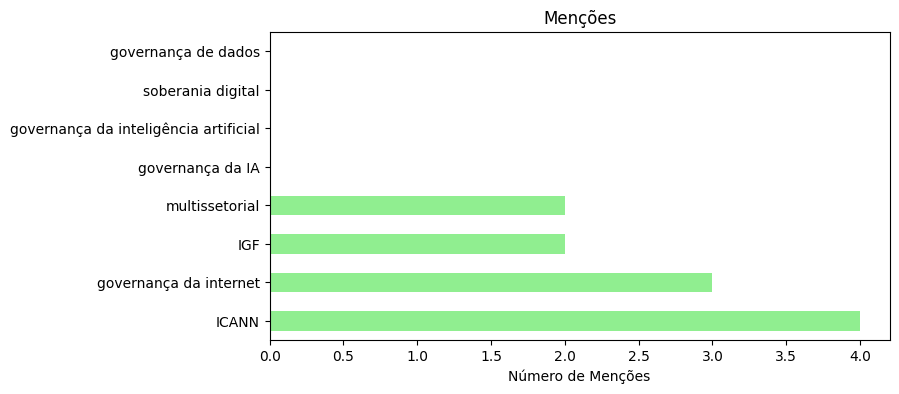

In [17]:
termos = [ 'soberania digital' , 'governança da internet', 'governança da inteligência artificial' , 'governança da IA' , 'governança de dados' , 'ICANN' , 'IGF','multissetorial' ]
frequencia = {}

for termo in termos:
    # Conta em quantos títulos a palavra aparece
    frequencia[termo] = df['texto_completo'].str.contains(termo, case=False).sum()

# Converter para série para facilitar a plotagem
ser_freq = pd.Series(frequencia)

plt.figure(figsize=(8, 4))
ser_freq.sort_values(ascending=False).plot(kind='barh', color='lightgreen')
plt.title('Menções')
plt.xlabel('Número de Menções')
plt.show()

In [18]:
df_customizado = df[["autoria","titulo",
       "data_atualizado", "horario_atualizado", "link", "paragrafos", "texto_completo","data_dt", "hora_int", "qtd_paragrafos", "tamanho_texto"]]
df_customizado

,autoria,titulo,data_atualizado,horario_atualizado,link,paragrafos,texto_completo,data_dt,hora_int,qtd_paragrafos,tamanho_texto
0,Ministério das Relações Exteriores,Incidente em Seul,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,O Governo brasileiro tomou conhecimento com gr...,incidente em seul o governo brasileiro tomou c...,2022-10-29,22.0,0,177
1,Ministério das Relações Exteriores,Nota Conjunta do Ministério das Relações Exter...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,A Comissão de Comércio Internacional dos Est...,nota conjunta do ministério das relações exter...,2022-10-27,11.0,0,717
2,Ministério das Relações Exteriores,Nota conjunta do Ministério das Relações Exter...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,"Em 19 de outubro, o Brasil depositou junto às...",nota conjunta do ministério das relações exter...,2022-10-25,17.0,0,129
3,Ministério das Relações Exteriores,Comunicado Conjunto entre os Ministros das Rel...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,Por ocasião da Visita Oficial do Ministro de ...,comunicado conjunto entre os ministros das rel...,2022-10-24,21.0,0,434
4,Ministério das Relações Exteriores,Nota conjunta do Ministério das Relações Exter...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,"Entre os dias 26 de setembro e 14 de outubro, ...",nota conjunta do ministério das relações exter...,2022-10-24,11.0,0,460
...,...,...,...,...,...,...,...,...,...,...,...
5164,NA,Cúpula de Chefes de Estado do MERCOSUL e Estad...,31/10/2022,17h45,https://www.gov.br/mre/pt-br/canais_atendiment...,"A Presidenta Dilma Rousseff participará, em Ca...",cúpula de chefes de estado do mercosul e estad...,2014-08-07,20.0,0,286
5165,NA,XLVI Reunião do Conselho do Mercado Comum e Cú...,31/10/2022,17h45,https://www.gov.br/mre/pt-br/canais_atendiment...,Informa-se o número do telefone celular do coo...,xlvi reunião do conselho do mercado comum e cú...,2014-08-07,20.0,0,213
5166,NA,Calendário de eventos entre 26 de julho e 03 d...,31/10/2022,17h45,https://www.gov.br/mre/pt-br/canais_atendiment...,"28 e 29/JUL – Rio de Janeiro, RJ. III Encontro...",calendário de eventos entre 26 de julho e 03 d...,2014-08-07,20.0,0,88
5167,NA,Cerimônia de posse do Presidente da República ...,31/10/2022,17h45,https://www.gov.br/mre/pt-br/canais_atendiment...,Os profissionais de imprensa interessados em p...,cerimônia de posse do presidente da república ...,2014-08-07,20.0,0,321


In [19]:
def buscar_termo(termo, onde='completo'):
    """
    Busca um termo nas notas do MRE e salva o resultado apenas em formato Excel no Google Drive.
    Se o arquivo já existir, ele será substituído pela versão mais recente.
    """
    import os

    # Caminho de destino solicitado
    diretorio_destino = '/content/gdrive/MyDrive/Colab_Notebooks/pibic-2025-2026/resultado-busca-palavras-notas/'

    # Cria a pasta caso ela não exista
    if not os.path.exists(diretorio_destino):
        os.makedirs(diretorio_destino)

    coluna = {
        'titulo': 'titulo',
        'texto': 'texto',
        'completo': 'texto_completo',
    }[onde]

    # busca case-insensitive
    mascara = df_customizado[coluna].str.contains(termo, case=False, na=False, regex=False)
    resultado = df_customizado[mascara].sort_values('data_dt', ascending=False)

    print(f"🔎 Termo: '{termo}'  |  Onde: {onde}")
    print(f"📌 Notas encontradas: {len(resultado)}")
    print("-" * 60)

    # Salvando apenas o arquivo Excel no Google Drive
    if not resultado.empty:
        nome_base = termo.replace(' ', '_')
        caminho_excel = os.path.join(diretorio_destino, f'{nome_base}.xlsx')

        # Verifica se já existe para informar a substituição
        if os.path.exists(caminho_excel):
            print(f"🔄 O arquivo '{nome_base}.xlsx' já existia e será substituído pela versão mais recente.")

        # Exportação para Excel (sobrescreve automaticamente)
        resultado.to_excel(caminho_excel, index=False)

        print(f"✅ Arquivo Excel atualizado com sucesso no Drive:")
        print(f"   - {caminho_excel}")
    else:
        print("\n⚠️ Nenhum resultado encontrado para salvar.")

    return resultado

In [20]:
buscar_termo('multissetorial', onde='completo')

🔎 Termo: 'multissetorial'  |  Onde: completo
📌 Notas encontradas: 2
------------------------------------------------------------
🔄 O arquivo 'multissetorial.xlsx' já existia e será substituído pela versão mais recente.
✅ Arquivo Excel atualizado com sucesso no Drive:
   - /content/gdrive/MyDrive/Colab_Notebooks/pibic-2025-2026/resultado-busca-palavras-notas/multissetorial.xlsx


,autoria,titulo,data_atualizado,horario_atualizado,link,paragrafos,texto_completo,data_dt,hora_int,qtd_paragrafos,tamanho_texto
4894,NA,Calendário de eventos entre 30 de agosto e 5 d...,07/10/2015,18h05,https://www.gov.br/mre/pt-br/canais_atendiment...,"31/AGO a 02/SET – Assunção, Paraguai. Reunião ...",calendário de eventos entre 30 de agosto e 5 d...,2015-08-29,21.0,0,2230
5081,NA,VI Cúpula BRICS – Declaração de Fortaleza – 15...,31/10/2022,17h45,https://www.gov.br/mre/pt-br/canais_atendiment...,"1. Nós, os líderes da República Federativa do ...",vi cúpula brics – declaração de fortaleza – 15...,2014-07-15,14.0,0,57109


In [21]:
buscar_termo('ICANN', onde='completo')

🔎 Termo: 'ICANN'  |  Onde: completo
📌 Notas encontradas: 4
------------------------------------------------------------
🔄 O arquivo 'ICANN.xlsx' já existia e será substituído pela versão mais recente.
✅ Arquivo Excel atualizado com sucesso no Drive:
   - /content/gdrive/MyDrive/Colab_Notebooks/pibic-2025-2026/resultado-busca-palavras-notas/ICANN.xlsx


,autoria,titulo,data_atualizado,horario_atualizado,link,paragrafos,texto_completo,data_dt,hora_int,qtd_paragrafos,tamanho_texto
2192,Ministério das Relações Exteriores,Solicitação de atribuição de domínio de primei...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,O Ministério das Relações Exteriores lament...,solicitação de atribuição de domínio de primei...,2019-05-20,19.0,0,379
2159,Ministério das Relações Exteriores,Solicitação de atribuição de domínio de primei...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,O Ministério das Relações Exteriores foi in...,solicitação de atribuição de domínio de primei...,2019-04-18,22.0,0,379
1704,Ministério das Relações Exteriores,Solicitação de atribuição do nome de domínio d...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,"Em 10 de março, o Conselho Diretor da Corpora...",solicitação de atribuição do nome de domínio d...,2019-03-11,16.0,0,704
3357,NA,Calendário de eventos entre 06 e 13 de novembr...,04/11/2016,21h59,https://www.gov.br/mre/pt-br/canais_atendiment...,"3/NOV a 9/NOV – Hyderabad, Índia. 57a Sessão P...",calendário de eventos entre 06 e 13 de novembr...,2016-11-04,19.0,0,62


In [22]:
buscar_termo('IGF', onde='completo')

🔎 Termo: 'IGF'  |  Onde: completo
📌 Notas encontradas: 2
------------------------------------------------------------
🔄 O arquivo 'IGF.xlsx' já existia e será substituído pela versão mais recente.
✅ Arquivo Excel atualizado com sucesso no Drive:
   - /content/gdrive/MyDrive/Colab_Notebooks/pibic-2025-2026/resultado-busca-palavras-notas/IGF.xlsx


,autoria,titulo,data_atualizado,horario_atualizado,link,paragrafos,texto_completo,data_dt,hora_int,qtd_paragrafos,tamanho_texto
4894,NA,Calendário de eventos entre 30 de agosto e 5 d...,07/10/2015,18h05,https://www.gov.br/mre/pt-br/canais_atendiment...,"31/AGO a 02/SET – Assunção, Paraguai. Reunião ...",calendário de eventos entre 30 de agosto e 5 d...,2015-08-29,21.0,0,2230
4081,NA,Calendário de eventos entre 14 a 22 de março d...,31/10/2022,17h30,https://www.gov.br/mre/pt-br/canais_atendiment...,"15 a 17/MAR – Boston, EUA – Seafood Expo North...",calendário de eventos entre 14 a 22 de março d...,2015-03-13,22.0,0,8488


In [23]:
buscar_termo('CGI.br', onde='completo')

🔎 Termo: 'CGI.br'  |  Onde: completo
📌 Notas encontradas: 2
------------------------------------------------------------
🔄 O arquivo 'CGI.br.xlsx' já existia e será substituído pela versão mais recente.
✅ Arquivo Excel atualizado com sucesso no Drive:
   - /content/gdrive/MyDrive/Colab_Notebooks/pibic-2025-2026/resultado-busca-palavras-notas/CGI.br.xlsx


,autoria,titulo,data_atualizado,horario_atualizado,link,paragrafos,texto_completo,data_dt,hora_int,qtd_paragrafos,tamanho_texto
317,Ministério das Relações Exteriores,Calendário de eventos entre 21 e 28 de setembr...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,"27/AGO a 21/SET (Continuação) – Genebra, Sui...",calendário de eventos entre 21 e 28 de setembr...,2018-09-26,20.0,0,3074
548,NA,Calendário de eventos entre 13 de fevereiro e ...,10/02/2017,21h50,https://www.gov.br/mre/pt-br/canais_atendiment...,"12/FEV a 14/FEV – Dubai, Emirados Árabes. Semi...",calendário de eventos entre 13 de fevereiro e ...,2017-02-10,21.0,0,2736


In [24]:
buscar_termo('governança global da inteligência artificial', onde='completo')

🔎 Termo: 'governança global da inteligência artificial'  |  Onde: completo
📌 Notas encontradas: 1
------------------------------------------------------------
🔄 O arquivo 'governança_global_da_inteligência_artificial.xlsx' já existia e será substituído pela versão mais recente.
✅ Arquivo Excel atualizado com sucesso no Drive:
   - /content/gdrive/MyDrive/Colab_Notebooks/pibic-2025-2026/resultado-busca-palavras-notas/governança_global_da_inteligência_artificial.xlsx


,autoria,titulo,data_atualizado,horario_atualizado,link,paragrafos,texto_completo,data_dt,hora_int,qtd_paragrafos,tamanho_texto
3438,Ministério das Relações Exteriores,Declaração dos Líderes do BRICS sobre Governan...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,.,declaração dos líderes do brics sobre governan...,2025-07-06,20.0,0,1


In [25]:
buscar_termo('governança da internet', onde='completo')

🔎 Termo: 'governança da internet'  |  Onde: completo
📌 Notas encontradas: 3
------------------------------------------------------------
🔄 O arquivo 'governança_da_internet.xlsx' já existia e será substituído pela versão mais recente.
✅ Arquivo Excel atualizado com sucesso no Drive:
   - /content/gdrive/MyDrive/Colab_Notebooks/pibic-2025-2026/resultado-busca-palavras-notas/governança_da_internet.xlsx


,autoria,titulo,data_atualizado,horario_atualizado,link,paragrafos,texto_completo,data_dt,hora_int,qtd_paragrafos,tamanho_texto
1862,NA,Calendário de eventos entre 6 e 12 de setembro...,01/10/2015,21h05,https://www.gov.br/mre/pt-br/canais_atendiment...,"06/SET – Ancara, Turquia. Lançamento da Inicia...",calendário de eventos entre 6 e 12 de setembro...,2015-09-04,21.0,0,2741
4894,NA,Calendário de eventos entre 30 de agosto e 5 d...,07/10/2015,18h05,https://www.gov.br/mre/pt-br/canais_atendiment...,"31/AGO a 02/SET – Assunção, Paraguai. Reunião ...",calendário de eventos entre 30 de agosto e 5 d...,2015-08-29,21.0,0,2230
5081,NA,VI Cúpula BRICS – Declaração de Fortaleza – 15...,31/10/2022,17h45,https://www.gov.br/mre/pt-br/canais_atendiment...,"1. Nós, os líderes da República Federativa do ...",vi cúpula brics – declaração de fortaleza – 15...,2014-07-15,14.0,0,57109


In [26]:
buscar_termo('digital', onde='completo')

🔎 Termo: 'digital'  |  Onde: completo
📌 Notas encontradas: 27
------------------------------------------------------------
🔄 O arquivo 'digital.xlsx' já existia e será substituído pela versão mais recente.
✅ Arquivo Excel atualizado com sucesso no Drive:
   - /content/gdrive/MyDrive/Colab_Notebooks/pibic-2025-2026/resultado-busca-palavras-notas/digital.xlsx


,autoria,titulo,data_atualizado,horario_atualizado,link,paragrafos,texto_completo,data_dt,hora_int,qtd_paragrafos,tamanho_texto
4520,Ministério das Relações Exteriores,"I Diálogo Digital Brasil-Índia - Brasília, 26 ...",NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,"Realizou-se hoje (26/11), em Brasília, a prim...","i diálogo digital brasil-índia - brasília, 26 ...",2025-11-26,21.0,0,311
3690,Ministério das Relações Exteriores,Seminário sobre economia de dados e desenvolvi...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,No âmbito da presidência brasileira do BRICS...,seminário sobre economia de dados e desenvolvi...,2025-03-18,19.0,0,464
3550,Ministério das Relações Exteriores,Diálogo Digital Brasil – União Europeia – Comu...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,Com base na sólida Parceria Estratégica Bras...,diálogo digital brasil – união europeia – comu...,2025-02-12,16.0,0,230
3552,Ministério das Relações Exteriores,Participação do Ministro Mauro Vieira na Cúpul...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,O Ministro Mauro Vieira chefiará a delegaçã...,participação do ministro mauro vieira na cúpul...,2025-02-09,14.0,0,463
5010,Ministério das Relações Exteriores,Declaração sobre Infraestrutura Pública Digita...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,Declaração sobre Infraestrutura Pública Dig...,declaração sobre infraestrutura pública digita...,2024-11-19,17.0,0,158
3937,Ministério das Relações Exteriores,Declaração Conjunta sobre a Aliança Digital Am...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,(tradução não oficial),declaração conjunta sobre a aliança digital am...,2023-07-17,16.0,0,25
2897,Ministério das Relações Exteriores,Conclusão das negociações do acordo sobre cons...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,"Após quase 20 anos de negociação, os Estado...",conclusão das negociações do acordo sobre cons...,2023-03-06,15.0,0,981
2129,Ministério das Relações Exteriores,Visita do Senhor Presidente da República à Arg...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,Em sua primeira missão ao exterior no atual m...,visita do senhor presidente da república à arg...,2023-01-21,10.0,0,3053
7,Ministério das Relações Exteriores,Nota conjunta do Ministério das Relações Exter...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,Após frutíferas tratativas entre o Brasil e ...,nota conjunta do ministério das relações exter...,2022-10-14,17.0,0,315
4047,Ministério das Relações Exteriores,Declaração Presidencial sobre a Integração Dig...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,"Os Presidentes da República da Argentina, Alb...",declaração presidencial sobre a integração dig...,2021-12-17,11.0,0,384


In [27]:
buscar_termo('inteligência artificial', onde='completo')

🔎 Termo: 'inteligência artificial'  |  Onde: completo
📌 Notas encontradas: 3
------------------------------------------------------------
🔄 O arquivo 'inteligência_artificial.xlsx' já existia e será substituído pela versão mais recente.
✅ Arquivo Excel atualizado com sucesso no Drive:
   - /content/gdrive/MyDrive/Colab_Notebooks/pibic-2025-2026/resultado-busca-palavras-notas/inteligência_artificial.xlsx


,autoria,titulo,data_atualizado,horario_atualizado,link,paragrafos,texto_completo,data_dt,hora_int,qtd_paragrafos,tamanho_texto
4566,Ministério das Relações Exteriores,Seleção de brasileiro ao Prêmio da UNESCO para...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,"O governo brasileiro recebeu, com grande satis...",seleção de brasileiro ao prêmio da unesco para...,2025-11-06,12.0,0,600
3438,Ministério das Relações Exteriores,Declaração dos Líderes do BRICS sobre Governan...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,.,declaração dos líderes do brics sobre governan...,2025-07-06,20.0,0,1
3552,Ministério das Relações Exteriores,Participação do Ministro Mauro Vieira na Cúpul...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,O Ministro Mauro Vieira chefiará a delegaçã...,participação do ministro mauro vieira na cúpul...,2025-02-09,14.0,0,463


In [28]:
buscar_termo('internet', onde='completo')

🔎 Termo: 'internet'  |  Onde: completo
📌 Notas encontradas: 14
------------------------------------------------------------
🔄 O arquivo 'internet.xlsx' já existia e será substituído pela versão mais recente.
✅ Arquivo Excel atualizado com sucesso no Drive:
   - /content/gdrive/MyDrive/Colab_Notebooks/pibic-2025-2026/resultado-busca-palavras-notas/internet.xlsx


,autoria,titulo,data_atualizado,horario_atualizado,link,paragrafos,texto_completo,data_dt,hora_int,qtd_paragrafos,tamanho_texto
4,Ministério das Relações Exteriores,Nota conjunta do Ministério das Relações Exter...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,"Entre os dias 26 de setembro e 14 de outubro, ...",nota conjunta do ministério das relações exter...,2022-10-24,11.0,0,460
3990,Ministério das Relações Exteriores,Declaração de Osaka dos Líderes do G20 para a ...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,"Como Líderes, uma de nossas maiores responsab...",declaração de osaka dos líderes do g20 para a ...,2019-06-29,14.0,0,479
2192,Ministério das Relações Exteriores,Solicitação de atribuição de domínio de primei...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,O Ministério das Relações Exteriores lament...,solicitação de atribuição de domínio de primei...,2019-05-20,19.0,0,379
2159,Ministério das Relações Exteriores,Solicitação de atribuição de domínio de primei...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,O Ministério das Relações Exteriores foi in...,solicitação de atribuição de domínio de primei...,2019-04-18,22.0,0,379
1704,Ministério das Relações Exteriores,Solicitação de atribuição do nome de domínio d...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,"Em 10 de março, o Conselho Diretor da Corpora...",solicitação de atribuição do nome de domínio d...,2019-03-11,16.0,0,704
317,Ministério das Relações Exteriores,Calendário de eventos entre 21 e 28 de setembr...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,"27/AGO a 21/SET (Continuação) – Genebra, Sui...",calendário de eventos entre 21 e 28 de setembr...,2018-09-26,20.0,0,3074
611,NA,Calendário de eventos entre 14 de agosto e 20 ...,18/08/2017,21h00,https://www.gov.br/mre/pt-br/canais_atendiment...,14 a 16/AGO – Brasília. Oficina de Trabalho Re...,calendário de eventos entre 14 de agosto e 20 ...,2017-08-11,20.0,0,185
1960,NA,Lançamento do Satélite Geoestacionário de Defe...,21/03/2017,15h28,https://www.gov.br/mre/pt-br/canais_atendiment...,"No próximo dia 21 de março, será lançado, do C...",lançamento do satélite geoestacionário de defe...,2017-03-18,13.0,0,497
548,NA,Calendário de eventos entre 13 de fevereiro e ...,10/02/2017,21h50,https://www.gov.br/mre/pt-br/canais_atendiment...,"12/FEV a 14/FEV – Dubai, Emirados Árabes. Semi...",calendário de eventos entre 13 de fevereiro e ...,2017-02-10,21.0,0,2736
4283,NA,Visita do Presidente da República ao Paraguai ...,04/10/2016,15h43,https://www.gov.br/mre/pt-br/canais_atendiment...,MEMORANDO DE ENTENDIMENTO ENTRE O GOVERNO DA R...,visita do presidente da república ao paraguai ...,2016-10-04,15.0,0,5294


In [29]:
buscar_termo(' amazon ', onde='completo')

🔎 Termo: ' amazon '  |  Onde: completo
📌 Notas encontradas: 3
------------------------------------------------------------
🔄 O arquivo '_amazon_.xlsx' já existia e será substituído pela versão mais recente.
✅ Arquivo Excel atualizado com sucesso no Drive:
   - /content/gdrive/MyDrive/Colab_Notebooks/pibic-2025-2026/resultado-busca-palavras-notas/_amazon_.xlsx


,autoria,titulo,data_atualizado,horario_atualizado,link,paragrafos,texto_completo,data_dt,hora_int,qtd_paragrafos,tamanho_texto
2192,Ministério das Relações Exteriores,Solicitação de atribuição de domínio de primei...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,O Ministério das Relações Exteriores lament...,solicitação de atribuição de domínio de primei...,2019-05-20,19.0,0,379
2159,Ministério das Relações Exteriores,Solicitação de atribuição de domínio de primei...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,O Ministério das Relações Exteriores foi in...,solicitação de atribuição de domínio de primei...,2019-04-18,22.0,0,379
1704,Ministério das Relações Exteriores,Solicitação de atribuição do nome de domínio d...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,"Em 10 de março, o Conselho Diretor da Corpora...",solicitação de atribuição do nome de domínio d...,2019-03-11,16.0,0,704


In [30]:
buscar_termo(' IA ', onde='completo')

🔎 Termo: ' IA '  |  Onde: completo
📌 Notas encontradas: 2
------------------------------------------------------------
🔄 O arquivo '_IA_.xlsx' já existia e será substituído pela versão mais recente.
✅ Arquivo Excel atualizado com sucesso no Drive:
   - /content/gdrive/MyDrive/Colab_Notebooks/pibic-2025-2026/resultado-busca-palavras-notas/_IA_.xlsx


,autoria,titulo,data_atualizado,horario_atualizado,link,paragrafos,texto_completo,data_dt,hora_int,qtd_paragrafos,tamanho_texto
4566,Ministério das Relações Exteriores,Seleção de brasileiro ao Prêmio da UNESCO para...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,"O governo brasileiro recebeu, com grande satis...",seleção de brasileiro ao prêmio da unesco para...,2025-11-06,12.0,0,600
5010,Ministério das Relações Exteriores,Declaração sobre Infraestrutura Pública Digita...,NA,NA,https://www.gov.br/mre/pt-br/canais_atendiment...,Declaração sobre Infraestrutura Pública Dig...,declaração sobre infraestrutura pública digita...,2024-11-19,17.0,0,158


## Palavras mais frequentes

Top 20 palavras nos TÍTULOS:
  brasil                    1329
  visita                    714
  conjunta                  559
  república                 521
  ministro                  493
  relações                  463
  exteriores                426
  brasília                  418
  presidente                405
  reunião                   387
  concessão                 384
  embaixador                381
  agrément                  370
  ministério                323
  declaração                293
  eventos                   292
  calendário                284
  ocasião                   237
  cúpula                    226
  comunicado                219


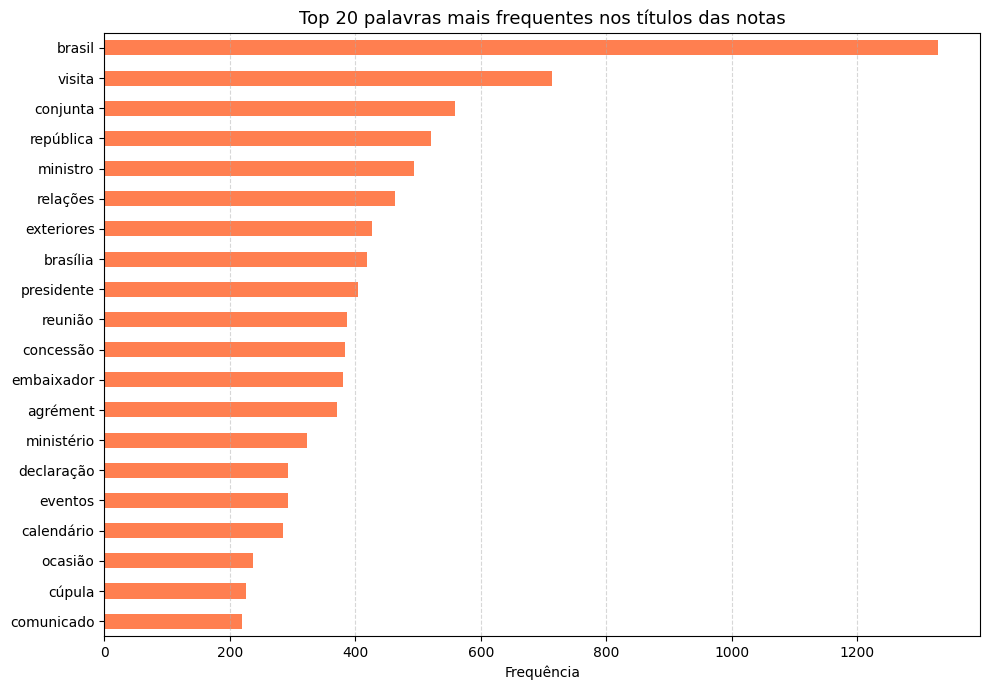

In [31]:
import re
from collections import Counter

# Stopwords em português (lista pequena, suficiente para começar)
STOPWORDS_PT = {
    'a', 'o', 'as', 'os', 'um', 'uma', 'uns', 'umas',
    'de', 'do', 'da', 'dos', 'das', 'em', 'no', 'na', 'nos', 'nas',
    'e', 'ou', 'mas', 'que', 'se', 'por', 'para', 'com', 'sem',
    'à', 'ao', 'às', 'aos', 'pelo', 'pela', 'pelos', 'pelas',
    'é', 'são', 'foi', 'ser', 'estar', 'tem', 'ter', 'há',
    'sobre', 'entre', 'até', 'após', 'pela', 'pelo',
    'sua', 'seu', 'suas', 'seus', 'este', 'esta', 'isso', 'esse', 'essa',
    'nº', 'n°', 'nota', 'notas', 'imprensa',  # específicas do contexto
}


def palavras_mais_frequentes(serie_texto, top_n=20, min_tamanho=4):
    """Conta as palavras mais frequentes em uma coluna de texto."""
    todas_palavras = []
    for texto in serie_texto.dropna():
        # \w+ pega sequências de letras/números; flags re.UNICODE pra acentos
        palavras = re.findall(r'\b[a-záàâãéêíóôõúüç]+\b', texto.lower(), flags=re.UNICODE)
        palavras = [p for p in palavras if p not in STOPWORDS_PT and len(p) >= min_tamanho]
        todas_palavras.extend(palavras)
    return Counter(todas_palavras).most_common(top_n)


top_palavras = palavras_mais_frequentes(df['titulo'], top_n=20)
print("Top 20 palavras nos TÍTULOS:")
for palavra, contagem in top_palavras:
    print(f"  {palavra:25s} {contagem}")

# Gráfico
serie = pd.Series(dict(top_palavras)).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 7))
serie.plot(kind='barh', ax=ax, color='coral')
ax.set_title('Top 20 palavras mais frequentes nos títulos das notas', fontsize=13)
ax.set_xlabel('Frequência')
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Nuvem de palavras

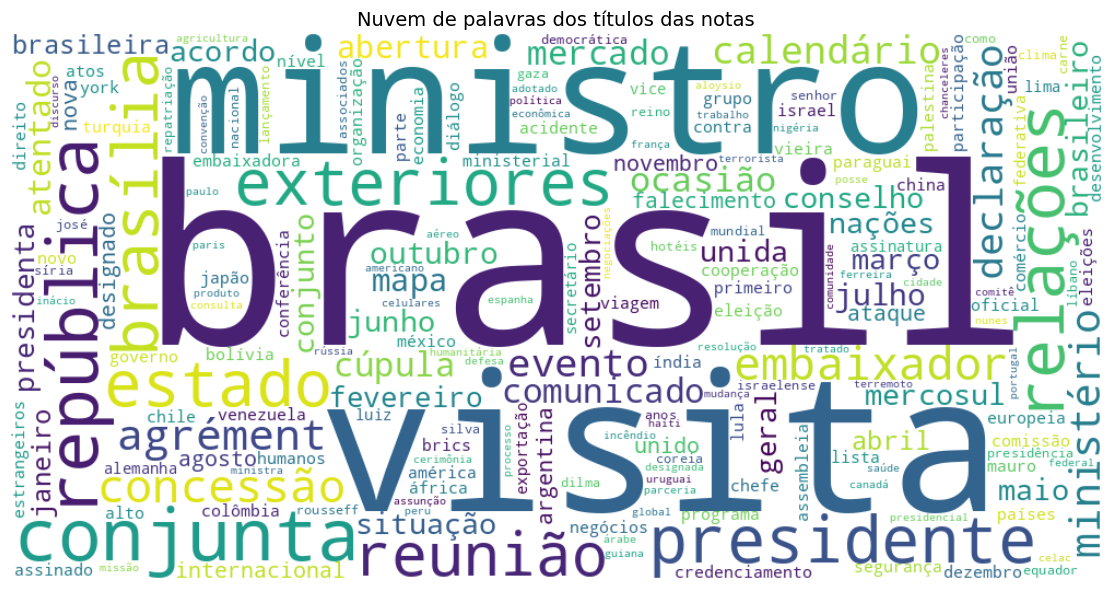

In [32]:
from wordcloud import WordCloud

# Junta todos os títulos em um único texto gigante
texto_titulos = ' '.join(df['titulo'].dropna()).lower()

# Remove stopwords usando o set já definido
wc = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    stopwords=STOPWORDS_PT,
    colormap='viridis',
    min_word_length=4,
    collocations=False,  # evita repetir bigramas
).generate(texto_titulos)

fig, ax = plt.subplots(figsize=(13, 6))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Nuvem de palavras dos títulos das notas', fontsize=14)
plt.tight_layout()
plt.show()


## Co-ocorrência de palavras

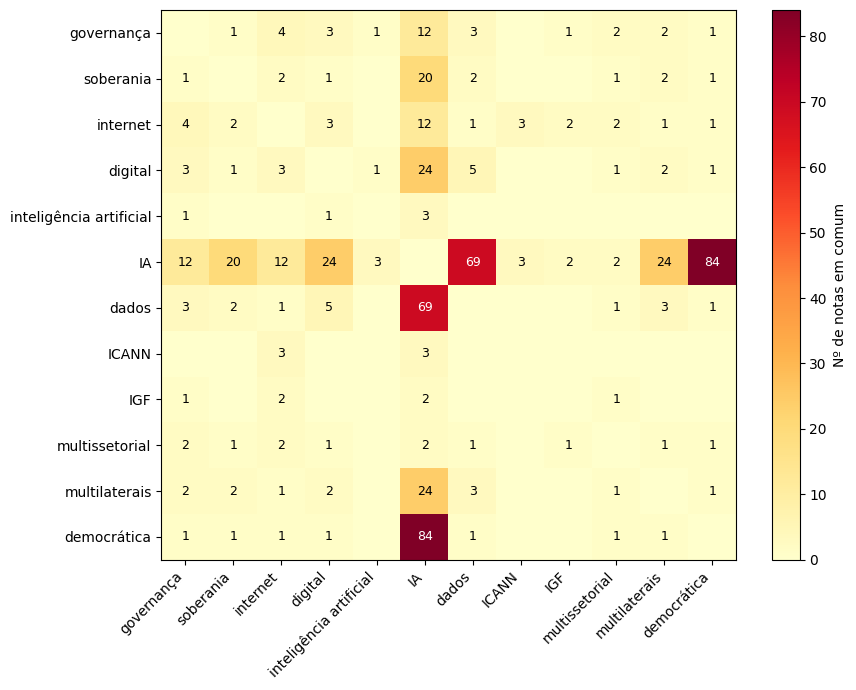

In [33]:
import numpy as np

palavras_analise = ['governança', 'soberania' , 'internet' , 'digital' , 'inteligência artificial' , 'IA' , 'dados' , 'ICANN' , 'IGF','multissetorial','multilaterais','democrática']

# Para cada nota, marca quais países são mencionados
matriz_presenca = pd.DataFrame({
    palavra: df['texto_completo'].str.contains(palavra, case=False, na=False, regex=False).astype(int)
    for palavra in palavras_analise
})

# Matriz de co-ocorrência (multiplicação matricial: notas onde A E B aparecem)
coocorrencia = matriz_presenca.T.dot(matriz_presenca)

# Zerar a diagonal (não interessa um país com ele mesmo)
np.fill_diagonal(coocorrencia.values, 0)

# Heatmap simples com matplotlib
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(coocorrencia, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(palavras_analise)))
ax.set_yticks(range(len(palavras_analise)))
ax.set_xticklabels(palavras_analise, rotation=45, ha='right')
ax.set_yticklabels(palavras_analise)


# Anotar os valores nas células
for i in range(len(palavras_analise)):
    for j in range(len(palavras_analise)):
        valor = coocorrencia.iloc[i, j]
        if valor > 0:
            ax.text(j, i, int(valor), ha='center', va='center',
                    color='black' if valor < coocorrencia.values.max()/2 else 'white',
                    fontsize=9)

plt.colorbar(im, ax=ax, label='Nº de notas em comum')
plt.tight_layout()
plt.show()


### Multissetorial

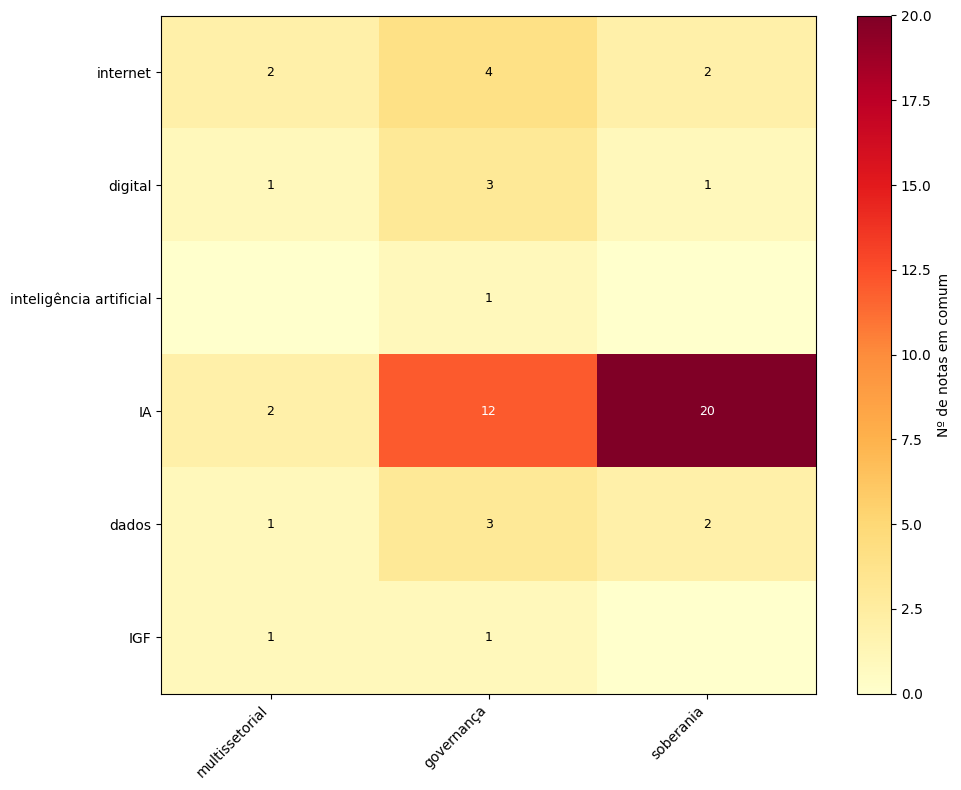

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Definir as palavras para os eixos vertical e horizontal
palavras_vertical = ['internet', 'digital', 'inteligência artificial', 'IA', 'dados', 'IGF']
palavras_horizontal = ['multissetorial', 'governança', 'soberania']

# Combinar todas as palavras para criar a matriz de presença inicial
palavras_analise_total = list(set(palavras_vertical + palavras_horizontal))

# Para cada nota, marca quais palavras são mencionadas
matriz_presenca = pd.DataFrame({
    palavra: df['texto_completo'].str.contains(palavra, case=False, na=False, regex=False).astype(int)
    for palavra in palavras_analise_total
})

# Matriz de co-ocorrência entre os dois conjuntos de palavras
# Linhas: palavras_vertical, Colunas: palavras_horizontal
coocorrencia_personalizada = matriz_presenca[palavras_vertical].T.dot(matriz_presenca[palavras_horizontal])

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(coocorrencia_personalizada, cmap='YlOrRd', aspect='auto')

# Configurar os rótulos dos eixos
ax.set_xticks(range(len(palavras_horizontal)))
ax.set_yticks(range(len(palavras_vertical)))
ax.set_xticklabels(palavras_horizontal, rotation=45, ha='right')
ax.set_yticklabels(palavras_vertical)

# Anotar os valores nas células
for i in range(len(palavras_vertical)):
    for j in range(len(palavras_horizontal)):
        valor = coocorrencia_personalizada.iloc[i, j]
        if valor > 0:
            ax.text(j, i, int(valor), ha='center', va='center',
                    color='black' if valor < coocorrencia_personalizada.values.max()/2 else 'white',
                    fontsize=9)

plt.colorbar(im, ax=ax, label='Nº de notas em comum')
plt.tight_layout()
plt.show()

### Multilateral

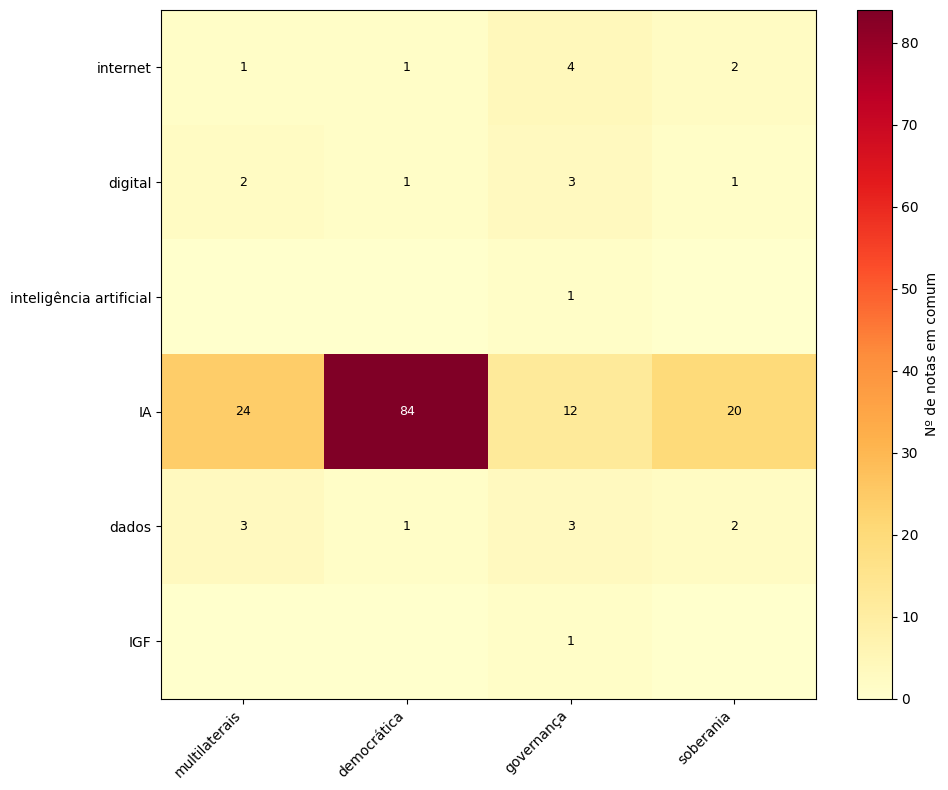

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Definir as palavras para os eixos vertical e horizontal
palavras_vertical = ['internet', 'digital', 'inteligência artificial', 'IA', 'dados', 'IGF']
palavras_horizontal = ['multilaterais','democrática', 'governança', 'soberania']

# Combinar todas as palavras para criar a matriz de presença inicial
palavras_analise_total = list(set(palavras_vertical + palavras_horizontal))

# Para cada nota, marca quais palavras são mencionadas
matriz_presenca = pd.DataFrame({
    palavra: df['texto_completo'].str.contains(palavra, case=False, na=False, regex=False).astype(int)
    for palavra in palavras_analise_total
})

# Matriz de co-ocorrência entre os dois conjuntos de palavras
# Linhas: palavras_vertical, Colunas: palavras_horizontal
coocorrencia_personalizada = matriz_presenca[palavras_vertical].T.dot(matriz_presenca[palavras_horizontal])

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(coocorrencia_personalizada, cmap='YlOrRd', aspect='auto')

# Configurar os rótulos dos eixos
ax.set_xticks(range(len(palavras_horizontal)))
ax.set_yticks(range(len(palavras_vertical)))
ax.set_xticklabels(palavras_horizontal, rotation=45, ha='right')
ax.set_yticklabels(palavras_vertical)

# Anotar os valores nas células
for i in range(len(palavras_vertical)):
    for j in range(len(palavras_horizontal)):
        valor = coocorrencia_personalizada.iloc[i, j]
        if valor > 0:
            ax.text(j, i, int(valor), ha='center', va='center',
                    color='black' if valor < coocorrencia_personalizada.values.max()/2 else 'white',
                    fontsize=9)

plt.colorbar(im, ax=ax, label='Nº de notas em comum')
plt.tight_layout()
plt.show()

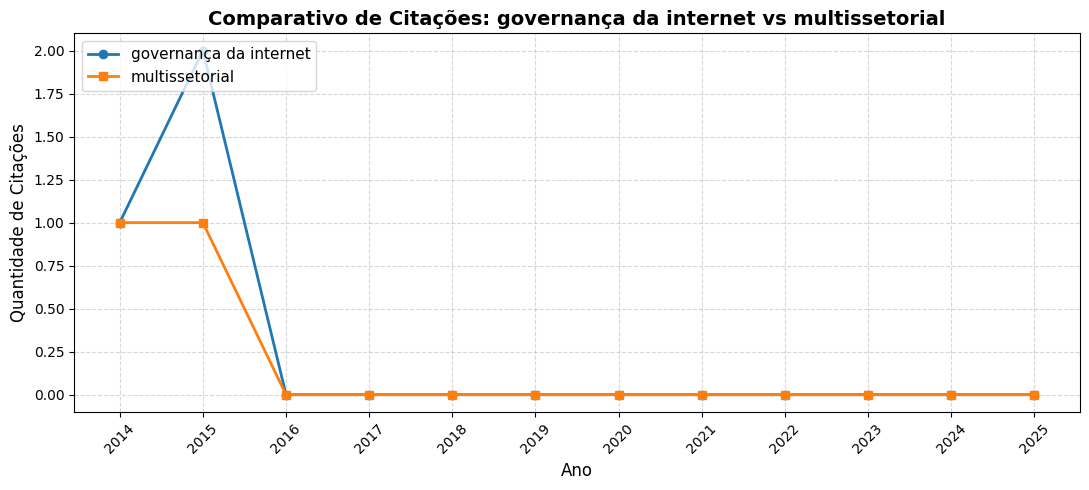

In [36]:
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================
# DIGITE AQUI AS DUAS PALAVRAS PARA COMPARAR
PALAVRA_A = "governança da internet"
PALAVRA_B = "multissetorial"
# ==========================================

# 1. Processamento para a PALAVRA A
dados_a = (
    df.groupby("ano")["texto_completo"]
    .apply(lambda x: x.astype(str).str.count(rf"\b{PALAVRA_A}\b", flags=2).sum())
    .reset_index(name="total")
)

# 2. Processamento para a PALAVRA B
dados_b = (
    df.groupby("ano")["texto_completo"]
    .apply(lambda x: x.astype(str).str.count(rf"\b{PALAVRA_B}\b", flags=2).sum())
    .reset_index(name="total")
)

# 3. Construir o gráfico comparativo
plt.figure(figsize=(11, 5))

# Linha da primeira palavra (Azul)
plt.plot(
    dados_a["ano"],
    dados_a["total"],
    marker="o",
    linestyle="-",
    color="#1f77b4",
    linewidth=2,
    label=PALAVRA_A,
)

# Linha da segunda palavra (Laranja/Vermelho)
plt.plot(
    dados_b["ano"],
    dados_b["total"],
    marker="s",
    linestyle="-",
    color="#ff7f0e",
    linewidth=2,
    label=PALAVRA_B,
)

# Configurações do gráfico
plt.title(
    f"Comparativo de Citações: {PALAVRA_A} vs {PALAVRA_B}",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Quantidade de Citações", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

# Garante que os anos fiquem bem distribuídos no eixo X usando a coluna "ano"
anos_unicos = sorted(df["ano"].unique())
plt.xticks(anos_unicos, rotation=45)

# Exibe a legenda identificando as cores de cada palavra
plt.legend(fontsize=11, loc="upper left")

plt.tight_layout()
plt.show()

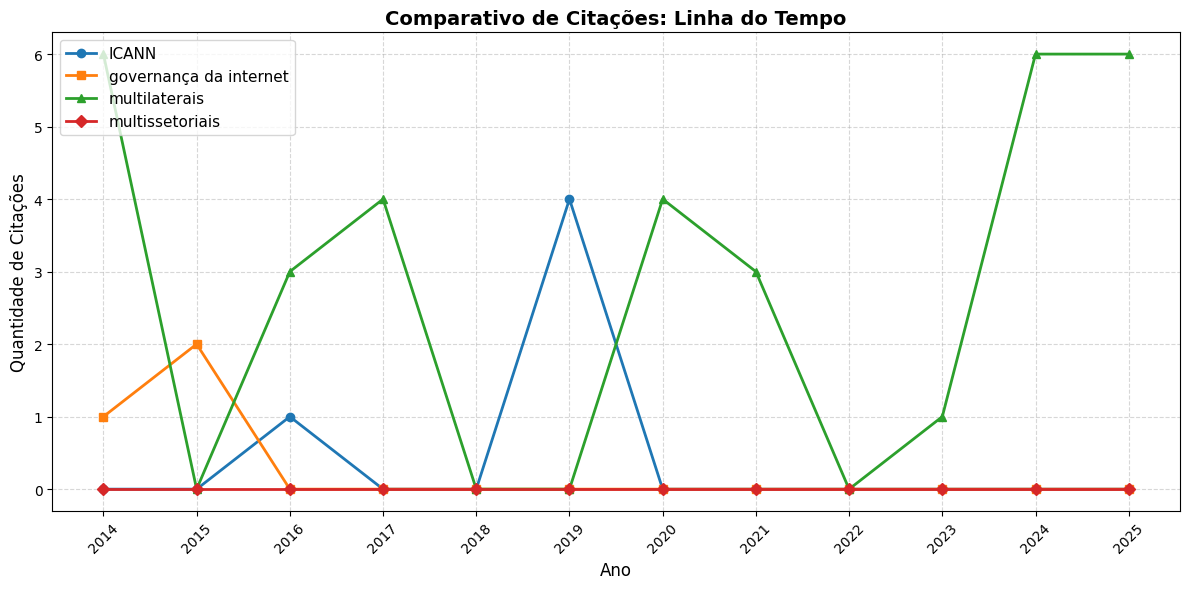

In [37]:
import matplotlib.pyplot as plt
import pandas as pd

# ====================================================================
# MODIFIQUE AQUI AS 4 PALAVRAS QUE VOCÊ DESEJA COMPARAR
PALAVRAS = ["ICANN", "governança da internet", "multilaterais", "multissetoriais"]
# ====================================================================

# Configuração de estilo para diferenciar as 4 linhas (cores e marcadores)
cores = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]  # Azul, Laranja, Verde, Vermelho
marcadores = ["o", "s", "^", "D"]  # Círculo, Quadrado, Triângulo, Losango

plt.figure(figsize=(12, 6))

# Loop para processar e plotar cada palavra automaticamente
for i, palavra in enumerate(PALAVRAS):
    # Agrupa por ano e conta as ocorrências da palavra atual
    dados_palavra = (
        df.groupby("ano")["texto_completo"]
        .apply(lambda x: x.astype(str).str.count(rf"\b{palavra}\b", flags=2).sum())
        .reset_index(name="total")
    )

    # Plota a linha correspondente no gráfico
    plt.plot(
        dados_palavra["ano"],
        dados_palavra["total"],
        marker=marcadores[i],
        linestyle="-",
        color=cores[i],
        linewidth=2,
        label=palavra,
    )

# Configurações do gráfico
plt.title(
    "Comparativo de Citações: Linha do Tempo", fontsize=14, fontweight="bold"
)
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Quantidade de Citações", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

# Ajusta os anos no eixo X baseado na sua coluna "ano"
anos_unicos = sorted(df["ano"].unique())
plt.xticks(anos_unicos, rotation=45)

# Exibe a legenda com as 4 palavras
plt.legend(fontsize=11, loc="upper left")

plt.tight_layout()
plt.show()

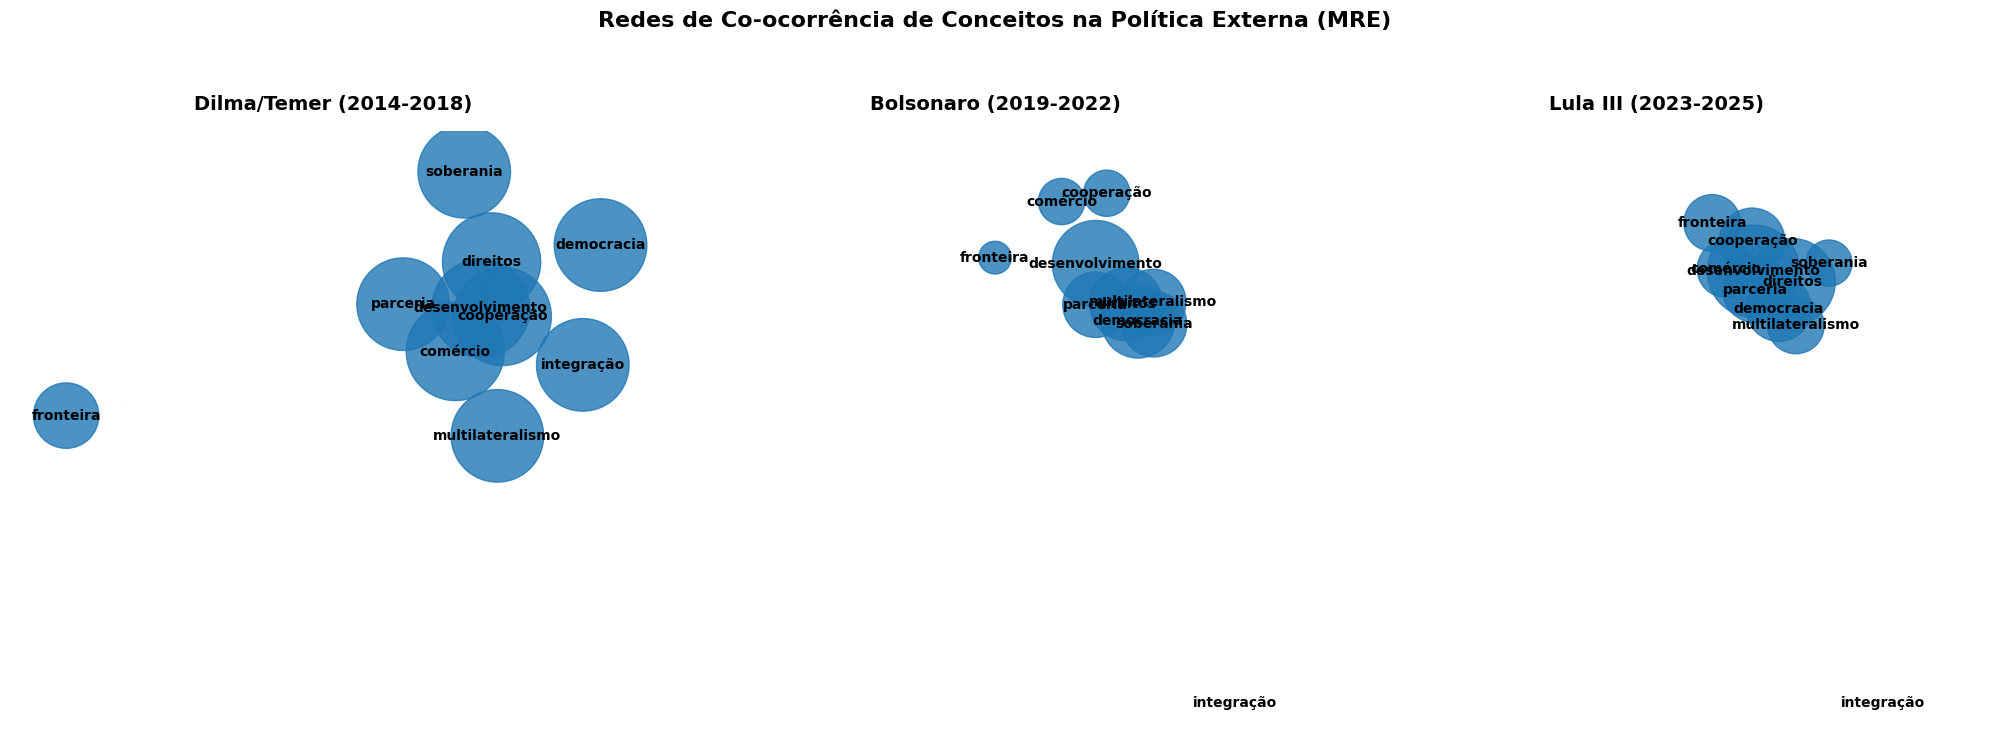

In [38]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# ====================================================================
# CONFIGURAÇÃO DE PARÂMETROS
# ====================================================================
# Escolha os termos que você quer analisar na rede (ex: termos de RI)
TERMOS_ALVO = [
    "multi",
    "cooperação",
    "fronteira",
    "parceria",
    "comércio",
    "desenvolvimento",
    "democracia",
    "direitos",
    "multilateralismo",
    "integração",
]

# Definição dos períodos políticos baseados na sua coluna "ano"
periodos = {
    "Dilma/Temer (2014-2018)": df[df["ano"].between(2014, 2018)],
    "Bolsonaro (2019-2022)": df[df["ano"].between(2019, 2022)],
    "Lula III (2023-2025)": df[df["ano"].between(2023, 2025)],
}

# Configuração da janela gráfica: 1 linha, 3 colunas (lado a lado)
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharex=True, sharey=True)
axes = axes.flatten()

# Loop para processar e plotar a rede de cada período político
for idx, (nome_periodo, df_periodo) in enumerate(periodos.items()):
    ax = axes[idx]

    # 1. Vetorização: Criar matriz de co-ocorrência para os termos alvo
    # Ignora maiúsculas/minúsculas e foca apenas no vocabulário escolhido
    vectorizer = CountVectorizer(vocabulary=TERMOS_ALVO, lowercase=True)
    X = vectorizer.fit_transform(df_periodo["texto_completo"].astype(str))

    # Matriz de co-ocorrência: termo x termo (multiplicação transposta)
    co_ocorrência = (X.T * X).toarray()

    # 2. Criar o Grafo usando NetworkX
    G = nx.from_numpy_array(co_ocorrência)
    # Mapear os índices numéricos de volta para as palavras
    mapeamento_nomes = {i: termo for i, termo in enumerate(TERMOS_ALVO)}
    G = nx.relabel_nodes(G, mapeamento_nomes)

    # Remover auto-loops (uma palavra conectada a ela mesma)
    G.remove_edges_from(nx.selfloop_edges(G))

    # 3. Calcular a Centralidade de Grau (Degree Centrality) para o tamanho dos nós
    centralidade = nx.degree_centrality(G)
    tamanhos_nos = [
        v * 5000 for v in centralidade.values()
    ]  # Multiplicador para ajuste visual

    # 4. Definir o Layout (Fruchterman-Reingold)
    # Usamos uma semente (seed) fixa para que a disposição inicial seja parecida entre os grafos
    pos = nx.fruchterman_reingold_layout(G, seed=42)

    # 5. Desenhar os componentes no eixo (ax) correspondente
    # Desenha as arestas (linhas) com transparência baseada no peso
    pesos_arestas = [G[u][v]["weight"] for u, v in G.edges()]
    # Normaliza os pesos para controle da largura da linha
    max_peso = max(pesos_arestas) if pesos_arestas else 1
    larguras = [(p / max_peso) * 4 for p in pesos_arestas]

    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.3, width=larguras, edge_color="gray")

    # Desenha os nós (círculos)
    nx.draw_networkx_nodes(
        G, pos, ax=ax, node_size=tamanhos_nos, node_color="#1f77b4", alpha=0.8
    )

    # Desenha os rótulos (textos) ajustados para legibilidade
    nx.draw_networkx_labels(
        G, pos, ax=ax, font_size=10, font_weight="bold", font_family="sans-serif"
    )

    # Configurações de título e estética por quadrante
    ax.set_title(nome_periodo, fontsize=14, fontweight="bold", pad=15)
    ax.axis("off")  # Oculta os eixos X e Y clássicos para limpar a rede

# Ajuste final do layout geral
plt.suptitle(
    "Redes de Co-ocorrência de Conceitos na Política Externa (MRE)",
    fontsize=16,
    fontweight="bold",
    y=1.05,
)
plt.tight_layout()
plt.show()

/tmp/ipykernel_9874/993272408.py:28: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_arena = df[df["texto_completo"].astype(str).str.contains(regex_arena, case=False, na=False)]
/tmp/ipykernel_9874/993272408.py:28: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_arena = df[df["texto_completo"].astype(str).str.contains(regex_arena, case=False, na=False)]


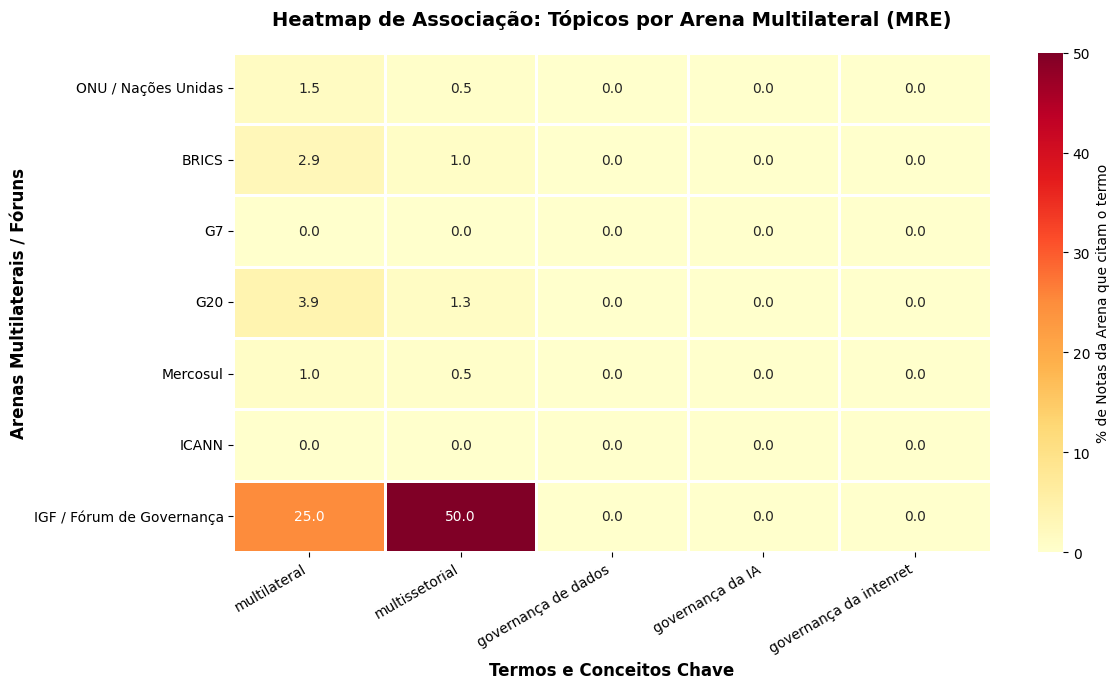

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ====================================================================
# CONFIGURAÇÃO DOS EIXOS DO HEATMAP
# ====================================================================
# Dicionário mapeando a Arena para os termos de busca que a identificam no texto
ARENAS = {
    "ONU / Nações Unidas": r"\b(ONU|Nações Unidas|Assembleia Geral)\b",
    "BRICS": r"\bBRICS\b",
    "G7": r"\bG7\b",
    "G20": r"\bG20\b",
    "Mercosul": r"\bMercosul\b",
    "ICANN": r"\bICANN\b",
    "IGF / Fórum de Governança": r"\b(IGF|Governança da Internet)\b",
}

# Termos que você quer analisar no eixo horizontal
PALAVRAS_CHAVE = ["multilateral", "multissetorial","governança de dados","governança da IA","governança da intenret"]

# 1. Construção da Matriz de Densidade
matriz_dados = []

for arena_nome, regex_arena in ARENAS.items():
    # Filtra as notas que pertencem/citam a arena atual
    df_arena = df[df["texto_completo"].astype(str).str.contains(regex_arena, case=False, na=False)]

    total_notas_arena = len(df_arena)
    linhas_frequencia = {}

    for palavra in PALAVRAS_CHAVE:
        if total_notas_arena > 0:
            # Conta em quantas notas daquela arena a palavra aparece pelo menos uma vez
            ocorrencias = df_arena["texto_completo"].astype(str).str.contains(rf"\b{palavra}\b", case=False, na=False).sum()
            # Calcula a densidade percentual (% de notas da arena que citam o termo)
            linhas_frequencia[palavra] = (ocorrencias / total_notas_arena) * 100
        else:
            linhas_frequencia[palavra] = 0.0

    matriz_dados.append(linhas_frequencia)

# Transforma a lista de dicionários em um DataFrame estruturado para o Seaborn
df_heatmap = pd.DataFrame(matriz_dados, index=ARENAS.keys())

# 2. Construção do Gráfico (Heatmap)
plt.figure(figsize=(12, 7))

# Escolha da paleta de cores (YlOrRd cria um gradiente intuitivo de densidade)
sns.heatmap(
    df_heatmap,
    annot=True,               # Mostra os valores percentuais dentro dos quadrados
    fmt=".1f",                # Formata com uma casa decimal
    cmap="YlOrRd",            # Gradiente Amarelo -> Laranja -> Vermelho
    linewidths=0.8,           # Linha sutil separando os blocos
    cbar_kws={'label': '% de Notas da Arena que citam o termo'}
)

# Configurações estéticas e alinhamento dos eixos
plt.title(
    "Heatmap de Associação: Tópicos por Arena Multilateral (MRE)",
    fontsize=14,
    fontweight="bold",
    pad=20
)
plt.ylabel("Arenas Multilaterais / Fóruns", fontsize=12, fontweight="bold")
plt.xlabel("Termos e Conceitos Chave", fontsize=12, fontweight="bold")

# Rotaciona os rótulos para melhor legibilidade
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Sua dúvida é excelente e toca exatamente no ponto central da **lógica de filtragem** do código!

Embora o seu banco de dados inteiro (`df`) seja composto **apenas por notas do MRE**, o Itamaraty escreve sobre assuntos completamente diferentes em cada nota. Uma nota pode ser sobre a visita do presidente ao Mercosul, outra sobre um discurso na Assembleia Geral da ONU, e outra sobre uma reunião técnica do G20.

O que o código faz é **recortar o banco do MRE em subgrupos (as Arenas)** usando palavras-chave, e depois analisar o comportamento interno de cada subgrupo.

---

### O Processo de Identificação em 3 Etapas

Imagine que o seu DataFrame original do MRE tem **1.000 notas**. O código processa linha por linha da seguinte forma:

#### 1. Criação dos Subgrupos (As Arenas)

O código olha para o texto completo de cada nota e procura por termos específicos (usando Expressões Regulares - Regex).

* Para a **Arena ONU**, ele filtra apenas as notas que contêm as palavras *"ONU"*, *"Nações Unidas"* ou *"Assembleia Geral"*.
* Suponhamos que, das 1.000 notas do MRE, ele encontre **200 notas** que mencionam a ONU. Essas 200 notas passam a ser o nosso "Universo ONU".
* Ele faz o mesmo para o G20. Digamos que encontre **100 notas** do MRE que citam o G20. Esse é o "Universo G20".

#### 2. A Contagem Incidental (As Palavras-Chave)

Agora, o código esquece o resto do banco de dados e trabalha **apenas dentro de cada universo** que ele separou:

* **Dentro das 200 notas da ONU:** Ele conta em quantas delas aparece a palavra *"direitos humanos"*. Digamos que apareça em **160 notas**.
* **Dentro das 100 notas do G20:** Ele conta em quantas delas aparece a palavra *"direitos humanos"*. Digamos que apareça em apenas **5 notas**.

#### 3. A Normalização (O Cálculo da Legenda)

Se plotássemos apenas o número bruto (160 vs 5), o gráfico estaria enviesado caso a ONU tivesse muito mais notas escritas do que o G20. Por isso, fazemos o cálculo percentual:

* **ONU:** $\frac{160 \text{ notas com o termo}}{200 \text{ notas totais da ONU}} \times 100 = \mathbf{80\%}$
* **G20:** $\frac{5 \text{ notas com o termo}}{100 \text{ notas totais do G20}} \times 100 = \mathbf{5\%}$

---

### O que o resultado final te diz (Teoria de RI)

Quando o Heatmap pintar um quadrado com **80%** na linha da ONU para "direitos humanos", a interpretação correta para a sua dissertação/tese é:

> *"Sempre que o MRE emite uma nota oficial mencionando a ONU, existe uma probabilidade de 80% de que ele inclua o conceito normativo de 'direitos humanos' no texto. Por outro lado, quando o MRE fala sobre o G20, essa probabilidade despenca para 5%."*

Isso prova empiricamente o **multilateralismo seletivo**: o MRE (que é a origem de todas as notas) muda drasticamente o seu vocabulário e as suas prioridades políticas dependendo de qual fórum internacional ele está performando ou relatando naquele momento.

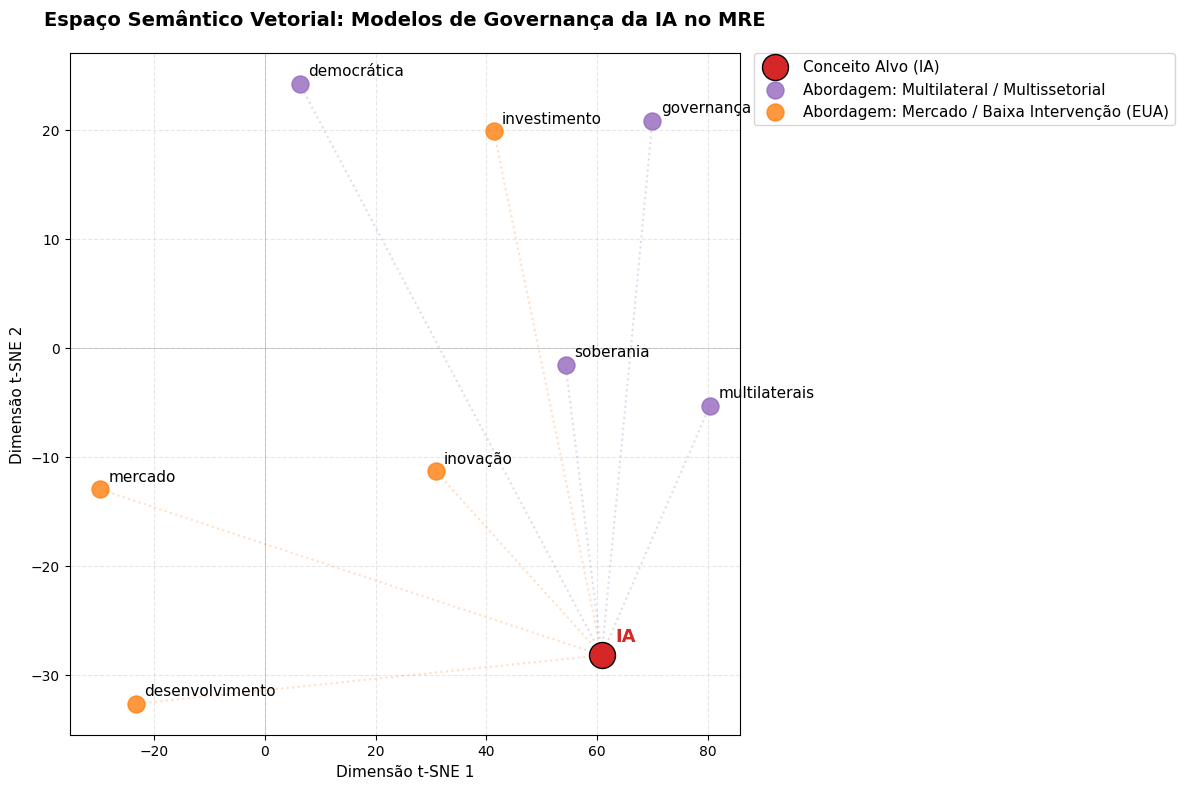

In [50]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gensim.models import Word2Vec
from sklearn.manifold import TSNE

# Omitir avisos de convergência do t-SNE para limpar o output
warnings.filterwarnings("ignore", category=FutureWarning)

# ====================================================================
# CONFIGURAÇÃO DOS NOVOS TERMOS DEFINIDOS POR VOCÊ
# ====================================================================
CONCEITO_CHAVE = "ia"

PERSPECTIVA_MULTILATERAL = [
    "multilaterais",
    "multissetoriais",
    "governança",
    "democrática",
    "soberania",
]

PERSPECTIVA_MERCADO = [
    "autorregulação",
    "inovação",
    "desenvolvimento",
    "mercado",
    "investimento",
]

TODOS_CONCEITOS = (
    [CONCEITO_CHAVE] + PERSPECTIVA_MULTILATERAL + PERSPECTIVA_MERCADO
)

# 1. Pré-processamento e Padronização do Corpus
corpus_tokenizado = [
    str(texto).lower().split() for texto in df["texto_completo"]
]

for documento in corpus_tokenizado:
    for i, palavra in enumerate(documento):
        if palavra in ["inteligência_artificial", "artificial"]:
            documento[i] = "ia"

# 2. Treinamento do Modelo Vetorial Word2Vec
modelo_w2v = Word2Vec(
    sentences=corpus_tokenizado,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    seed=42,
)

conceitos_presentes = [
    p for p in TODOS_CONCEITOS if p in modelo_w2v.wv.key_to_index
]
vetores = np.array([modelo_w2v.wv[p] for p in conceitos_presentes])

# 3. Redução de Dimensionalidade com t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=min(5, len(conceitos_presentes) - 1),
    random_state=42,
    n_iter=1000,
)
coordenadas_2d = tsne.fit_transform(vetores)

# 4. Construção do Gráfico de Dispersão (Scatter Plot)
plt.figure(figsize=(12, 8))  # Ajustado o tamanho para acomodar a legenda ao lado

x_coords = coordenadas_2d[:, 0]
y_coords = coordenadas_2d[:, 1]
idx_ia = conceitos_presentes.index(CONCEITO_CHAVE)

for i, palavra in enumerate(conceitos_presentes):
    if palavra == CONCEITO_CHAVE:
        plt.scatter(
            x_coords[i],
            y_coords[i],
            color="#d62728",
            edgecolors="black",
            s=350,
            zorder=5,
            label="Conceito Alvo (IA)",
        )
        plt.annotate(
            palavra.upper(),
            (x_coords[i], y_coords[i]),
            xytext=(10, 10),
            textcoords="offset points",
            fontsize=13,
            weight="bold",
            color="#d62728",
        )

    elif palavra in PERSPECTIVA_MULTILATERAL:
        plt.scatter(
            x_coords[i],
            y_coords[i],
            color="#9467bd",
            s=150,
            alpha=0.8,
            zorder=4,
            label=(
                "Abordagem: Multilateral / Multissetorial"
                if "Abordagem: Multilateral / Multissetorial"
                not in plt.gca().get_legend_handles_labels()[1]
                else ""
            ),
        )
        plt.annotate(
            palavra,
            (x_coords[i], y_coords[i]),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=11,
        )
        plt.plot(
            [x_coords[idx_ia], x_coords[i]],
            [y_coords[idx_ia], y_coords[i]],
            color="#9467bd",
            linestyle=":",
            alpha=0.25,
        )

    elif palavra in PERSPECTIVA_MERCADO:
        plt.scatter(
            x_coords[i],
            y_coords[i],
            color="#ff7f0e",
            s=150,
            alpha=0.8,
            zorder=4,
            label=(
                "Abordagem: Mercado / Baixa Intervenção (EUA)"
                if "Abordagem: Mercado / Baixa Intervenção (EUA)"
                not in plt.gca().get_legend_handles_labels()[1]
                else ""
            ),
        )
        plt.annotate(
            palavra,
            (x_coords[i], y_coords[i]),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=11,
        )
        plt.plot(
            [x_coords[idx_ia], x_coords[i]],
            [y_coords[idx_ia], y_coords[i]],
            color="#ff7f0e",
            linestyle=":",
            alpha=0.25,
        )

# Configurações do Espaço Vetorial
plt.title(
    "Espaço Semântico Vetorial: Modelos de Governança da IA no MRE",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Dimensão t-SNE 1", fontsize=11)
plt.ylabel("Dimensão t-SNE 2", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.3)

plt.axhline(0, color="gray", linewidth=0.5, alpha=0.5)
plt.axvline(0, color="gray", linewidth=0.5, alpha=0.5)

# ====================================================================
# MODIFICAÇÃO: LEGENDA POSICIONADA FORA DA ÁREA ÚTIL DO GRÁFICO
# ====================================================================
# bbox_to_anchor=(1.02, 1) joga a legenda para a direita do eixo principal
plt.legend(
    loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=11, borderaxespad=0
)

plt.tight_layout()
plt.show()

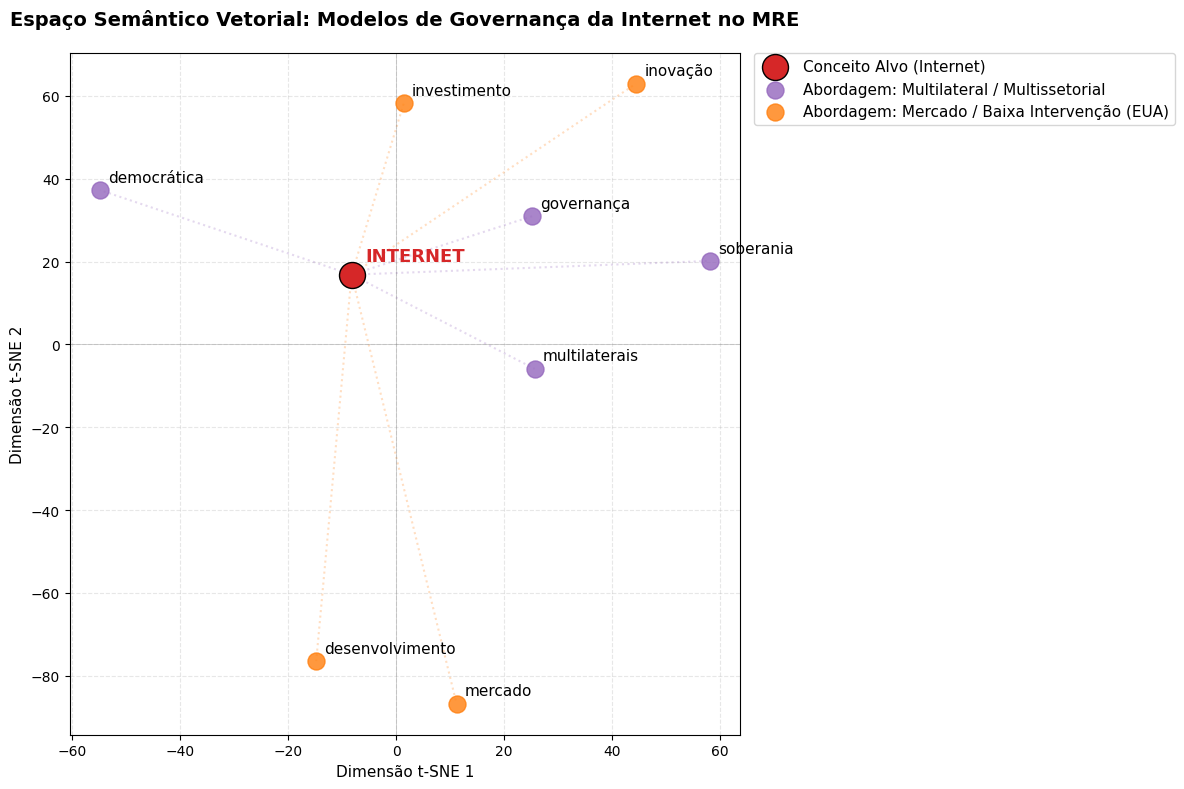

In [52]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gensim.models import Word2Vec
from sklearn.manifold import TSNE

# Omitir avisos de convergência do t-SNE para limpar o output
warnings.filterwarnings("ignore", category=FutureWarning)

# ====================================================================
# CONFIGURAÇÃO DO NOVO CONCEITO ALVO E MESMOS PARÂMETROS
# ====================================================================
CONCEITO_CHAVE = "internet"  # Alterado para focar na Internet

PERSPECTIVA_MULTILATERAL = [
    "multilaterais",
    "multissetoriais",
    "governança",
    "democrática",
    "soberania",
]

PERSPECTIVA_MERCADO = [
    "autorregulação",
    "inovação",
    "desenvolvimento",
    "mercado",
    "investimento",
]

TODOS_CONCEITOS = (
    [CONCEITO_CHAVE] + PERSPECTIVA_MULTILATERAL + PERSPECTIVA_MERCADO
)

# 1. Pré-processamento e Padronização do Corpus
corpus_tokenizado = [
    str(texto).lower().split() for texto in df["texto_completo"]
]

# Garantir que variações de escrita apontem para o termo em minúsculo
for documento in corpus_tokenizado:
    for i, palavra in enumerate(documento):
        if palavra in ["internet", "web", "rede_mundial"]:
            documento[i] = "internet"

# 2. Treinamento do Modelo Vetorial Word2Vec
modelo_w2v = Word2Vec(
    sentences=corpus_tokenizado,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    seed=42,
)

# Filtrar apenas os conceitos que aparecem no seu texto específico
conceitos_presentes = [
    p for p in TODOS_CONCEITOS if p in modelo_w2v.wv.key_to_index
]
vetores = np.array([modelo_w2v.wv[p] for p in conceitos_presentes])

# 3. Redução de Dimensionalidade com t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=min(5, len(conceitos_presentes) - 1),
    random_state=42,
    n_iter=1000,
)
coordenadas_2d = tsne.fit_transform(vetores)

# 4. Construção do Gráfico de Dispersão (Scatter Plot)
plt.figure(figsize=(12, 8))

x_coords = coordenadas_2d[:, 0]
y_coords = coordenadas_2d[:, 1]
idx_alvo = conceitos_presentes.index(CONCEITO_CHAVE)

for i, palavra in enumerate(conceitos_presentes):
    if palavra == CONCEITO_CHAVE:
        # Destaque para o termo INTERNET
        plt.scatter(
            x_coords[i],
            y_coords[i],
            color="#d62728",
            edgecolors="black",
            s=350,
            zorder=5,
            label="Conceito Alvo (Internet)",
        )
        plt.annotate(
            palavra.upper(),
            (x_coords[i], y_coords[i]),
            xytext=(10, 10),
            textcoords="offset points",
            fontsize=13,
            weight="bold",
            color="#d62728",
        )

    elif palavra in PERSPECTIVA_MULTILATERAL:
        plt.scatter(
            x_coords[i],
            y_coords[i],
            color="#9467bd",
            s=150,
            alpha=0.8,
            zorder=4,
            label=(
                "Abordagem: Multilateral / Multissetorial"
                if "Abordagem: Multilateral / Multissetorial"
                not in plt.gca().get_legend_handles_labels()[1]
                else ""
            ),
        )
        plt.annotate(
            palavra,
            (x_coords[i], y_coords[i]),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=11,
        )
        plt.plot(
            [x_coords[idx_alvo], x_coords[i]],
            [y_coords[idx_alvo], y_coords[i]],
            color="#9467bd",
            linestyle=":",
            alpha=0.25,
        )

    elif palavra in PERSPECTIVA_MERCADO:
        plt.scatter(
            x_coords[i],
            y_coords[i],
            color="#ff7f0e",
            s=150,
            alpha=0.8,
            zorder=4,
            label=(
                "Abordagem: Mercado / Baixa Intervenção (EUA)"
                if "Abordagem: Mercado / Baixa Intervenção (EUA)"
                not in plt.gca().get_legend_handles_labels()[1]
                else ""
            ),
        )
        plt.annotate(
            palavra,
            (x_coords[i], y_coords[i]),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=11,
        )
        plt.plot(
            [x_coords[idx_alvo], x_coords[i]],
            [y_coords[idx_alvo], y_coords[i]],
            color="#ff7f0e",
            linestyle=":",
            alpha=0.25,
        )

# Configurações Estéticas do Espaço Vetorial
plt.title(
    "Espaço Semântico Vetorial: Modelos de Governança da Internet no MRE",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Dimensão t-SNE 1", fontsize=11)
plt.ylabel("Dimensão t-SNE 2", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.3)

plt.axhline(0, color="gray", linewidth=0.5, alpha=0.5)
plt.axvline(0, color="gray", linewidth=0.5, alpha=0.5)

# Legenda posicionada fora da área útil para não tampar a visualização dos dados
plt.legend(
    loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=11, borderaxespad=0
)

plt.tight_layout()
plt.show()